# 04 — Meteorological Driver Diagnostics of Flash Drought (ALL-EVENT + CASE STUDIES)

Notebook ini mendiagnosis **kondisi meteorologis yang menyertai perkembangan flash drought**
setelah deteksi FD dan regionalisasi pulau selesai.

## Dua tingkat analisis

### A. All-event mechanism — 1996–2024

Seluruh **M1 grid-cell event starts** digunakan untuk membentuk composite onset-aligned:

- precipitation anomaly;
- T2M anomaly;
- D2M anomaly;
- VPD anomaly;

pada lag −6 sampai +6 pentad, secara nasional dan per macro-island.

Tujuannya adalah memperoleh pola meteorologis umum yang menyertai onset FD,
bukan hanya pola pada beberapa tahun ekstrem.

### B. Case-study mechanism

Empat robust national cases dianalisis lebih detail:

- 2003
- 1997
- 2015
- 2014

Tahun 2004 dipertahankan sebagai **supplementary sensitivity-dependent case**.

## Input meteorologi

Folder:

`D:\ERA5_LAND\ADD`

Variabel:

1. `total_precipitation` — 1995-01 s.d. 2025-12;
2. `2m_temperature` — 1995-01 s.d. 2025-12;
3. `2m_dewpoint_temperature` — 1995-01 s.d. 2025-12.

**VPD tidak perlu didownload.** VPD dihitung dari T2M dan D2M pada resolusi hourly
sebelum agregasi harian dan pentad.

## Guardrail interpretasi

Notebook ini menganalisis **associated meteorological conditions**.
Composite/anomali tidak dengan sendirinya membuktikan kausalitas.

**Tidak ada deteksi flash drought ulang di Notebook 04.**


## 1. Imports

In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("once")

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)
print("Xarray:", xr.__version__)


NumPy : 2.4.6
Pandas: 3.0.5
Xarray: 2026.7.0


## 2. Konfigurasi — path sudah diisi

In [2]:
ADD_DIR = Path(r"D:\ERA5_LAND\ADD")
NOTEBOOK03C_DIR = Path(r"D:\ERA5_LAND\output_fd_03c_island")
NOTEBOOK03B_DIR = Path(r"D:\ERA5_LAND\output_fd_03b_sensitivity")

OUTPUT_DIR = Path(r"D:\ERA5_LAND\output_fd_04_drivers")
YEARLY_PENTAD_DIR = OUTPUT_DIR / "yearly_pentad"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
YEARLY_PENTAD_DIR.mkdir(parents=True, exist_ok=True)

START_YEAR = 1995
END_YEAR = 2025
YEARS = list(range(START_YEAR, END_YEAR + 1))

PRIMARY_METHOD = "M1"

MAIN_CASE_YEARS = [2003, 1997, 2015, 2014]
SUPPLEMENTARY_CASE_YEARS = [2004]
CASE_YEARS = MAIN_CASE_YEARS + SUPPLEMENTARY_CASE_YEARS

DRIVER_WINDOW_RADIUS = 6

# All-event composite menggunakan event starts 1996–2024.
ALL_EVENT_START_YEAR = 1996
ALL_EVENT_END_YEAR = 2024
ALL_EVENT_LAGS = list(range(-6, 7))
PRE_ONSET_LAGS = [-2, -1, 0]

PRECIPITATION_MODE = "auto"  # auto | cumulative | deaccumulated

FORCE_REBUILD_YEARLY = False
FORCE_REBUILD_CLIMATOLOGY = False
FORCE_REBUILD_REGIONAL = False
FORCE_REBUILD_ALL_EVENT = False

TIME_CHUNK_HOURS = 24 * 7
LAT_CHUNK = 40
LON_CHUNK = 50

MIN_CLIMATOLOGY_YEARS = 20

SAVE_PNG = True
SAVE_PDF = True
FIGURE_DPI = 250

print("Meteorological input :", ADD_DIR)
print("03c input            :", NOTEBOOK03C_DIR)
print("03b input            :", NOTEBOOK03B_DIR)
print("04 output            :", OUTPUT_DIR)


Meteorological input : D:\ERA5_LAND\ADD
03c input            : D:\ERA5_LAND\output_fd_03c_island
03b input            : D:\ERA5_LAND\output_fd_03b_sensitivity
04 output            : D:\ERA5_LAND\output_fd_04_drivers


## 3. Data tambahan yang tidak diwajibkan

Untuk Notebook 04 inti, data yang sudah tersedia **cukup**:

- total precipitation;
- T2M;
- D2M;
- VPD diturunkan dari T2M + D2M.

Tidak perlu menunggu:

- evapotranspiration;
- wind speed;
- surface radiation;
- surface pressure;
- ENSO/IOD indices.

ET/radiasi/wind/pressure dapat ditambahkan bila penelitian dikembangkan menuju
potential evapotranspiration, EDDI, atau surface-energy-budget.

ENSO dan IOD lebih rapi dianalisis sesudah pola lokal precipitation–T2M–VPD jelas,
sebagai **large-scale climate context**.

Notebook 04 sekarang juga menggunakan file M1 dari Notebook 03b hanya untuk mengambil
**event-start flag**. FD tidak dideteksi ulang.


## 4. Temukan otomatis file meteorologi

In [3]:
if not ADD_DIR.exists():
    raise FileNotFoundError(ADD_DIR)

SUPPORTED_EXTENSIONS = {".nc", ".nc4", ".cdf"}

all_met_files = [
    p for p in ADD_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
]

if not all_met_files:
    raise FileNotFoundError(f"Tidak ada file NetCDF di {ADD_DIR}.")


def files_matching_any(tokens):
    tokens = [t.lower() for t in tokens]
    return sorted([
        path for path in all_met_files
        if any(token in path.name.lower() for token in tokens)
    ])


precip_files = files_matching_any([
    "total_precipitation",
    "precipitation",
])

dew_files = files_matching_any([
    "2m_dewpoint_temperature",
    "dewpoint",
])

t2m_files = [
    p for p in files_matching_any([
        "2m_temperature",
        "temperature",
    ])
    if "dew" not in p.name.lower()
]

print("Total precipitation files:", len(precip_files))
print("2m temperature files      :", len(t2m_files))
print("2m dewpoint files         :", len(dew_files))

if not precip_files:
    raise FileNotFoundError("File total_precipitation tidak ditemukan.")
if not t2m_files:
    raise FileNotFoundError("File 2m_temperature tidak ditemukan.")
if not dew_files:
    raise FileNotFoundError("File 2m_dewpoint_temperature tidak ditemukan.")

print("\nContoh:")
print("TP :", precip_files[0].name)
print("T2M:", t2m_files[0].name)
print("D2M:", dew_files[0].name)


Total precipitation files: 372
2m temperature files      : 372
2m dewpoint files         : 372

Contoh:
TP : total_precipitation_1995_01.nc
T2M: 2m_temperature_1995_01.nc
D2M: 2m_dewpoint_temperature_1995_01.nc


## 5. Indeks file per tahun-bulan

In [4]:
YEAR_MONTH_PATTERN = re.compile(
    r"(?P<year>19\d{2}|20\d{2})[_-](?P<month>0[1-9]|1[0-2])"
)


def build_month_map(files, label):
    mapping = {}

    for path in files:
        match = YEAR_MONTH_PATTERN.search(path.name)
        if match is None:
            continue

        key = (
            int(match.group("year")),
            int(match.group("month")),
        )

        if key in mapping:
            raise RuntimeError(
                f"{label}: duplicate file untuk {key}: "
                f"{mapping[key].name} dan {path.name}"
            )

        mapping[key] = path

    expected = {
        (year, month)
        for year in YEARS
        for month in range(1, 13)
    }

    missing = sorted(expected.difference(mapping))

    print(
        f"{label}: {len(mapping)} file terpetakan; "
        f"missing 1995–2025 = {len(missing)}"
    )

    if missing:
        print("Contoh missing:", missing[:12])

    return mapping


precip_map = build_month_map(precip_files, "TP")
t2m_map = build_month_map(t2m_files, "T2M")
dew_map = build_month_map(dew_files, "D2M")

for label, mapping in [
    ("TP", precip_map),
    ("T2M", t2m_map),
    ("D2M", dew_map),
]:
    missing = [
        (y, m)
        for y in YEARS
        for m in range(1, 13)
        if (y, m) not in mapping
    ]

    if missing:
        raise FileNotFoundError(
            f"{label}: file bulanan hilang: {missing[:20]}"
        )


TP: 372 file terpetakan; missing 1995–2025 = 0
T2M: 372 file terpetakan; missing 1995–2025 = 0
D2M: 372 file terpetakan; missing 1995–2025 = 0


## 6. Buka mask pulau dan timing Notebook 03c

In [5]:
ISLAND_MASK_FILE = (
    NOTEBOOK03C_DIR / "fd_island_masks_era5land_grid.nc"
)

NATIONAL_FD_FILE = (
    NOTEBOOK03C_DIR / "fd_M1_national_pentad_metrics_1995_2025.csv"
)

CASE_CORE_PEAK_FILE = (
    NOTEBOOK03C_DIR / "fd_M1_case_year_national_peak_pentads.csv"
)

ISLAND_FD_PENTAD_FILE = (
    NOTEBOOK03C_DIR / "fd_island_pentad_metrics_1995_2025.csv"
)

required_03c = [
    ISLAND_MASK_FILE,
    NATIONAL_FD_FILE,
    CASE_CORE_PEAK_FILE,
    ISLAND_FD_PENTAD_FILE,
]

missing_03c = [p for p in required_03c if not p.exists()]

if missing_03c:
    raise FileNotFoundError(
        "Output 03c belum lengkap:\n"
        + "\n".join(str(p) for p in missing_03c)
    )

island_mask_ds = xr.open_dataset(ISLAND_MASK_FILE)

valid_grid = (
    island_mask_ds["indonesia_valid_grid_mask"] > 0
).transpose("latitude", "longitude").load()

island_valid_grid_mask = (
    island_mask_ds["island_valid_grid_mask"] > 0
).transpose("island", "latitude", "longitude").load()

island_names = [
    str(v) for v in island_valid_grid_mask["island"].values
]

latitude = valid_grid["latitude"]
longitude = valid_grid["longitude"]

national_fd = pd.read_csv(NATIONAL_FD_FILE)
case_core_peaks_03c = pd.read_csv(CASE_CORE_PEAK_FILE)
island_fd_pentad = pd.read_csv(ISLAND_FD_PENTAD_FILE)

print("Indonesia valid grids:", f"{int(valid_grid.sum()):,}")
print("Macro-islands:", island_names)
display(case_core_peaks_03c)


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


Indonesia valid grids: 14,857
Macro-islands: ['Sumatra', 'Jawa', 'Kalimantan', 'Sulawesi', 'Bali-Nusa Tenggara', 'Maluku', 'Papua']


,year,case_class,national_peak_time_index,national_peak_pentad,national_peak_drought_core_area_percent,national_new_onset_area_at_peak_percent
0,2003,robust_national_case,616,33,82.068881,1.845631
1,1997,robust_national_case,177,32,72.667859,0.725570
2,2015,robust_national_case,1498,39,70.586039,0.208800
3,2014,robust_national_case,1394,8,59.677940,1.515136
4,2004,regional_sensitivity_case,685,29,51.872052,0.000000


## 6b. Temukan M1 detection file dari Notebook 03b

File ini digunakan **hanya** untuk membaca `fd_event_start` pada setiap grid dan pentad.

All-event composite tidak mendeteksi ulang FD dan tidak mengubah threshold M1.


In [6]:
if not NOTEBOOK03B_DIR.exists():
    raise FileNotFoundError(NOTEBOOK03B_DIR)


def resolve_m1_detection_file():
    preferred = [
        NOTEBOOK03B_DIR / "fd_detection_M1_1995_2025_indonesia.nc",
        NOTEBOOK03B_DIR / "fd_detection_M1_1995_2025_indonesia_masked.nc",
    ]

    for path in preferred:
        if path.exists():
            return path

    matches = sorted([
        path for path in NOTEBOOK03B_DIR.glob("*.nc")
        if re.search(r"(^|[_-])M1([_-]|$)", path.name, flags=re.I)
        and "1995_2025" in path.name
        and "indonesia" in path.name.lower()
    ])

    if len(matches) == 1:
        return matches[0]

    raise FileNotFoundError(
        "M1 detection file tidak dapat ditentukan otomatis.\n"
        f"Kandidat: {[p.name for p in matches]}"
    )


M1_DETECTION_FILE = resolve_m1_detection_file()

m1_detection_ds = xr.open_dataset(
    M1_DETECTION_FILE,
    chunks={
        "time_index": 73,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    },
    mask_and_scale=False,
)

if "fd_event_start" not in m1_detection_ds:
    raise KeyError(
        f"fd_event_start tidak ada pada {M1_DETECTION_FILE.name}"
    )

m1_event_start = (
    (m1_detection_ds["fd_event_start"] == 1)
    .where(valid_grid, False)
)

print("M1 detection:", M1_DETECTION_FILE)
print("M1 event-start dims:", dict(m1_event_start.sizes))


C:\Users\User\AppData\Local\Temp\ipykernel_11408\1414399951.py:33: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 40. This could degrade performance. Instead, consider rechunking after loading.
  m1_detection_ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_11408\1414399951.py:33: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  m1_detection_ds = xr.open_dataset(


M1 detection: D:\ERA5_LAND\output_fd_03b_sensitivity\fd_detection_M1_1995_2025_indonesia.nc
M1 event-start dims: {'time_index': 2263, 'latitude': 171, 'longitude': 461}


## 7. Fungsi normalisasi NetCDF ERA5-Land

In [7]:
TIME_NAMES = ["time", "valid_time"]
LAT_NAMES = ["latitude", "lat"]
LON_NAMES = ["longitude", "lon"]


def normalize_dataset(ds):
    rename = {}

    if "time" not in ds.dims and "time" not in ds.coords:
        for name in TIME_NAMES:
            if name in ds.dims or name in ds.coords:
                rename[name] = "time"
                break

    if "latitude" not in ds.dims and "latitude" not in ds.coords:
        for name in LAT_NAMES:
            if name in ds.dims or name in ds.coords:
                rename[name] = "latitude"
                break

    if "longitude" not in ds.dims and "longitude" not in ds.coords:
        for name in LON_NAMES:
            if name in ds.dims or name in ds.coords:
                rename[name] = "longitude"
                break

    if rename:
        ds = ds.rename(rename)

    required = {"time", "latitude", "longitude"}

    if not required.issubset(set(ds.coords) | set(ds.dims)):
        raise KeyError(
            f"Koordinat wajib tidak ditemukan. "
            f"Dims={dict(ds.sizes)}, coords={list(ds.coords)}"
        )

    ds = ds.sortby("time")

    if ds.indexes["time"].has_duplicates:
        ds = ds.isel(
            time=~ds.indexes["time"].duplicated()
        )

    return ds


def choose_variable(ds, candidates, label):
    for name in candidates:
        if name in ds.data_vars:
            return name

    vars_ = list(ds.data_vars)

    if len(vars_) == 1:
        print(f"{label}: memakai satu-satunya variable {vars_[0]!r}")
        return vars_[0]

    raise KeyError(
        f"{label}: variable tidak ditemukan. "
        f"Candidates={candidates}; tersedia={vars_}"
    )


VAR_CANDIDATES = {
    "tp": ["tp", "total_precipitation"],
    "t2m": ["t2m", "2m_temperature", "temperature_2m"],
    "d2m": ["d2m", "2m_dewpoint_temperature", "dewpoint_temperature_2m"],
}


def open_files(paths):
    ds = xr.open_mfdataset(
        [str(p) for p in paths],
        combine="by_coords",
        chunks={
            "time": TIME_CHUNK_HOURS,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
        parallel=False,
    )
    return normalize_dataset(ds)


def snap_to_analysis_grid(da):
    out = da.sel(
        latitude=latitude,
        longitude=longitude,
        method="nearest",
        tolerance=0.051,
    )

    return out.assign_coords(
        latitude=latitude,
        longitude=longitude,
    )


## 8. QC metadata dan variable names

In [8]:
sample_tp_ds = normalize_dataset(
    xr.open_dataset(precip_map[(START_YEAR, 1)])
)
sample_t_ds = normalize_dataset(
    xr.open_dataset(t2m_map[(START_YEAR, 1)])
)
sample_d_ds = normalize_dataset(
    xr.open_dataset(dew_map[(START_YEAR, 1)])
)

TP_VAR = choose_variable(
    sample_tp_ds, VAR_CANDIDATES["tp"], "TP"
)
T2M_VAR = choose_variable(
    sample_t_ds, VAR_CANDIDATES["t2m"], "T2M"
)
D2M_VAR = choose_variable(
    sample_d_ds, VAR_CANDIDATES["d2m"], "D2M"
)

print("TP variable :", TP_VAR)
print("T2M variable:", T2M_VAR)
print("D2M variable:", D2M_VAR)

print("\nTP attrs:", sample_tp_ds[TP_VAR].attrs)
print("\nT2M attrs:", sample_t_ds[T2M_VAR].attrs)
print("\nD2M attrs:", sample_d_ds[D2M_VAR].attrs)

sample_tp_ds.close()
sample_t_ds.close()
sample_d_ds.close()


TP variable : tp
T2M variable: t2m
D2M variable: d2m

TP attrs: {'GRIB_paramId': np.int64(228), 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': np.int64(78831), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'accum', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': np.int64(0), 'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(461), 'GRIB_Ny': np.int64(171), 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'tp', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.1), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.1), 'GRIB_jPointsAreConsecutive': np.int64(0), 'GRIB_jScansPositively': np.int64(0), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(6.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(-11.0), 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(95.0), 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(141.0), 'GRIB_missingValue': np.float

## 9. Deteksi otomatis tipe precipitation

Untuk ERA5-Land hourly gridded biasa, precipitation dapat berupa cumulative accumulation
dari 00 UTC. Produk tertentu yang sudah dipostproses dapat menyimpan hourly increment.

Notebook memeriksa pola intra-hari pada satu grid Indonesia. Jika hasil ambigu,
notebook berhenti agar precipitation tidak salah diproses.


In [9]:
def detect_precipitation_mode():
    if PRECIPITATION_MODE in {"cumulative", "deaccumulated"}:
        return PRECIPITATION_MODE

    ds = normalize_dataset(
        xr.open_dataset(precip_map[(START_YEAR, 1)])
    )

    var = choose_variable(
        ds, VAR_CANDIDATES["tp"], "TP"
    )

    da = snap_to_analysis_grid(ds[var])

    valid_indices = np.argwhere(valid_grid.values)
    iy, ix = valid_indices[len(valid_indices) // 2]

    series = (
        da.isel(latitude=int(iy), longitude=int(ix))
        .sel(time=slice(f"{START_YEAR}-01-01", f"{START_YEAR}-01-10"))
        .load()
        .to_series()
        .dropna()
    )

    ds.close()

    if len(series) < 48:
        raise RuntimeError(
            "Sample precipitation terlalu pendek."
        )

    frame = pd.DataFrame(
        {"value": series.values},
        index=pd.DatetimeIndex(series.index),
    )

    frame["date"] = frame.index.date
    frame["hour"] = frame.index.hour

    ratios = []

    for _, group in frame.groupby("date"):
        group = group.sort_index()

        subset = group[
            group["hour"].between(1, 23)
        ]["value"]

        if len(subset) < 12:
            continue

        diffs = np.diff(subset.values.astype(float))
        finite = np.isfinite(diffs)

        if finite.any():
            tolerance = max(
                1e-12,
                np.nanmax(np.abs(subset.values)) * 1e-8,
            )
            ratios.append(
                np.mean(diffs[finite] >= -tolerance)
            )

    if not ratios:
        raise RuntimeError(
            "Tidak cukup data untuk mendeteksi mode precipitation."
        )

    monotonic_fraction = float(np.mean(ratios))

    print(
        "TP intra-day non-decreasing fraction:",
        f"{monotonic_fraction:.3f}",
    )

    if monotonic_fraction >= 0.95:
        return "cumulative"

    if monotonic_fraction <= 0.80:
        return "deaccumulated"

    raise RuntimeError(
        "Mode precipitation ambigu. "
        f"Monotonic fraction={monotonic_fraction:.3f}. "
        "Set PRECIPITATION_MODE manual setelah memeriksa sumber."
    )


DETECTED_PRECIPITATION_MODE = detect_precipitation_mode()

print(
    "Detected precipitation mode:",
    DETECTED_PRECIPITATION_MODE,
)


TP intra-day non-decreasing fraction: 0.986
Detected precipitation mode: cumulative


## 10. Konversi T, Td, VPD, dan precipitation

In [10]:
def temperature_to_celsius(da):
    units = str(da.attrs.get("units", "")).lower().strip()

    if units == "k" or "kelvin" in units:
        out = da - 273.15
    else:
        sample = float(
            da.isel(
                time=0,
                latitude=da.sizes["latitude"] // 2,
                longitude=da.sizes["longitude"] // 2,
            ).compute()
        )
        out = da - 273.15 if sample > 100 else da

    out.attrs["units"] = "degC"
    return out


def saturation_vapor_pressure_kpa(temp_c):
    # Worden et al. (2021), Reviews of Geophysics.
    return (
        0.611
        * np.exp(
            17.5 * temp_c
            / (temp_c + 240.978)
        )
    )


def compute_vpd_kpa(t_c, td_c):
    es = saturation_vapor_pressure_kpa(t_c)
    ea = saturation_vapor_pressure_kpa(td_c)

    raw = es - ea

    vpd = xr.where(raw < 0, 0, raw)
    vpd.attrs["units"] = "kPa"

    return vpd


def precipitation_to_mm(da):
    units = str(da.attrs.get("units", "")).lower().strip()

    if units == "m" or "metre" in units:
        out = da * 1000.0
    elif "mm" in units:
        out = da
    else:
        print(
            "PERINGATAN: unit TP tidak dikenali:",
            repr(units),
            "→ diasumsikan metre dan dikali 1000."
        )
        out = da * 1000.0

    out.attrs["units"] = "mm"
    return out


## 11. Daily aggregation dan no-leap calendar

In [11]:
def strict_daily_mean(da):
    index = pd.DatetimeIndex(da["time"].values)

    counts = (
        pd.Series(1, index=index)
        .resample("1D")
        .sum()
    )

    valid_dates = counts[counts == 24].index

    return (
        da.resample(time="1D")
        .mean()
        .sel(time=valid_dates)
    )


def daily_precipitation(da_mm, target_year):
    index = pd.DatetimeIndex(da_mm["time"].values)

    if DETECTED_PRECIPITATION_MODE == "deaccumulated":
        counts = (
            pd.Series(1, index=index)
            .resample("1D")
            .sum()
        )

        valid_dates = counts[counts == 24].index

        daily = (
            da_mm.resample(time="1D")
            .sum()
            .sel(time=valid_dates)
        )

    elif DETECTED_PRECIPITATION_MODE == "cumulative":
        midnight = da_mm.sel(
            time=da_mm["time"].dt.hour == 0
        )

        shifted_time = (
            pd.DatetimeIndex(midnight["time"].values)
            - pd.Timedelta(days=1)
        )

        daily = midnight.assign_coords(
            time=shifted_time
        )

    else:
        raise ValueError(DETECTED_PRECIPITATION_MODE)

    return daily.sel(
        time=slice(
            f"{target_year}-01-01",
            f"{target_year}-12-31",
        )
    )


def expected_no_leap_dates(year):
    dates = pd.date_range(
        f"{year}-01-01",
        f"{year}-12-31",
        freq="1D",
    )

    return dates[
        ~(
            (dates.month == 2)
            & (dates.day == 29)
        )
    ]


def reindex_no_leap(daily, year):
    expected = expected_no_leap_dates(year)

    daily = daily.sel(
        time=~(
            (daily["time"].dt.month == 2)
            & (daily["time"].dt.day == 29)
        )
    )

    return daily.reindex(time=expected)


def daily_to_pentad(daily, reducer):
    if daily.sizes["time"] != 365:
        raise ValueError(
            f"Expected 365 no-leap slots, got {daily.sizes['time']}."
        )

    pentad = (
        np.arange(365, dtype=np.int16) // 5
    ) + 1

    daily = daily.assign_coords(
        pentad=("time", pentad)
    )

    if reducer == "sum":
        return daily.groupby("pentad").sum(
            dim="time",
            skipna=False,
        )

    if reducer == "mean":
        return daily.groupby("pentad").mean(
            dim="time",
            skipna=False,
        )

    raise ValueError(reducer)


## 12. Preprocessing tahunan → pentad

Notebook memproses satu tahun sekali agar penggunaan RAM/Dask tetap terkendali.

Output tahunan:

- precipitation pentad `[mm / 5 days]`;
- T2M pentad mean `[°C]`;
- D2M pentad mean `[°C]`;
- VPD pentad mean `[kPa]`.

Jika TP cumulative, Januari tahun berikutnya dipakai untuk memperoleh total 31 Desember.
Karena data berhenti Desember 2025, TP hari terakhir 2025 dapat missing; ini tidak
memengaruhi tahun kasus utama.


In [12]:
def files_for_year(mapping, year, include_next_january=False):
    paths = [
        mapping[(year, month)]
        for month in range(1, 13)
    ]

    if include_next_january and (year + 1, 1) in mapping:
        paths.append(mapping[(year + 1, 1)])

    return paths


def write_yearly_pentad(year):
    output_file = (
        YEARLY_PENTAD_DIR
        / f"meteorological_drivers_pentad_{year}.nc"
    )

    if output_file.exists() and not FORCE_REBUILD_YEARLY:
        print(year, "→ cache")
        return output_file

    print(year, "→ processing")

    t_ds = open_files(files_for_year(t2m_map, year))
    d_ds = open_files(files_for_year(dew_map, year))

    include_next = (
        DETECTED_PRECIPITATION_MODE == "cumulative"
    )

    p_ds = open_files(
        files_for_year(
            precip_map,
            year,
            include_next_january=include_next,
        )
    )

    try:
        t_var = choose_variable(
            t_ds, VAR_CANDIDATES["t2m"], "T2M"
        )
        d_var = choose_variable(
            d_ds, VAR_CANDIDATES["d2m"], "D2M"
        )
        p_var = choose_variable(
            p_ds, VAR_CANDIDATES["tp"], "TP"
        )

        t = snap_to_analysis_grid(t_ds[t_var]).sel(
            time=slice(
                f"{year}-01-01",
                f"{year}-12-31 23:59:59",
            )
        )

        d = snap_to_analysis_grid(d_ds[d_var]).sel(
            time=slice(
                f"{year}-01-01",
                f"{year}-12-31 23:59:59",
            )
        )

        p = snap_to_analysis_grid(p_ds[p_var])

        t, d = xr.align(t, d, join="exact")

        t_c = temperature_to_celsius(t)
        d_c = temperature_to_celsius(d)
        vpd = compute_vpd_kpa(t_c, d_c)

        t_daily = reindex_no_leap(
            strict_daily_mean(t_c), year
        )
        d_daily = reindex_no_leap(
            strict_daily_mean(d_c), year
        )
        vpd_daily = reindex_no_leap(
            strict_daily_mean(vpd), year
        )

        p_mm = precipitation_to_mm(p)
        p_daily = reindex_no_leap(
            daily_precipitation(p_mm, year),
            year,
        )

        ds_out = xr.Dataset({
            "tp_mm": daily_to_pentad(
                p_daily, "sum"
            ).astype(np.float32),

            "t2m_c": daily_to_pentad(
                t_daily, "mean"
            ).astype(np.float32),

            "d2m_c": daily_to_pentad(
                d_daily, "mean"
            ).astype(np.float32),

            "vpd_kpa": daily_to_pentad(
                vpd_daily, "mean"
            ).astype(np.float32),
        })

        ds_out = ds_out.expand_dims(
            year=[year]
        )

        ds_out.attrs.update({
            "title": (
                "ERA5-Land pentad meteorological drivers "
                "for flash-drought diagnosis"
            ),
            "year": int(year),
            "calendar": (
                "365-day no-leap; Feb 29 removed; "
                "73 pentads of 5 days"
            ),
            "precipitation_mode": DETECTED_PRECIPITATION_MODE,
            "vpd_formula": (
                "0.611*exp(17.5*T/(T+240.978)) - "
                "0.611*exp(17.5*Td/(Td+240.978)); kPa"
            ),
            "created_utc": str(pd.Timestamp.now(tz="UTC")),
        })

        encoding = {
            name: {
                "zlib": True,
                "complevel": 4,
                "dtype": "float32",
            }
            for name in ds_out.data_vars
        }

        ds_out.to_netcdf(
            output_file,
            encoding=encoding,
        )

    finally:
        t_ds.close()
        d_ds.close()
        p_ds.close()

    print(year, "→ saved", output_file.name)

    return output_file


## 13. Jalankan / gunakan cache preprocessing

In [13]:
yearly_files = [
    write_yearly_pentad(year)
    for year in YEARS
]

print("Yearly pentad files:", len(yearly_files))


1995 → cache
1996 → cache
1997 → cache
1998 → cache
1999 → cache
2000 → cache
2001 → cache
2002 → cache
2003 → cache
2004 → cache
2005 → cache
2006 → cache
2007 → cache
2008 → cache
2009 → cache
2010 → cache
2011 → cache
2012 → cache
2013 → cache
2014 → cache
2015 → cache
2016 → cache
2017 → cache
2018 → cache
2019 → cache
2020 → cache
2021 → cache
2022 → cache
2023 → cache
2024 → cache
2025 → cache
Yearly pentad files: 31


## 14. QC yearly pentad files

In [14]:
qc_rows = []

for path in yearly_files:
    ds = xr.open_dataset(path)
    year = int(ds["year"].values[0])

    row = {
        "year": year,
        "pentad_count": int(ds.sizes["pentad"]),
    }

    for var in ["tp_mm", "t2m_c", "d2m_c", "vpd_kpa"]:
        spatial_count = (
            ds[var]
            .where(valid_grid)
            .count(("latitude", "longitude"))
            .values
        )

        row[f"{var}_valid_pentads"] = int(
            np.count_nonzero(spatial_count > 0)
        )

    qc_rows.append(row)
    ds.close()

yearly_qc = pd.DataFrame(qc_rows)

YEARLY_QC_FILE = (
    OUTPUT_DIR / "meteorological_yearly_pentad_qc.csv"
)

yearly_qc.to_csv(
    YEARLY_QC_FILE,
    index=False,
)

display(yearly_qc.tail())

if not (yearly_qc["pentad_count"] == 73).all():
    raise AssertionError(
        "Tidak semua tahun memiliki 73 pentad."
    )


,year,pentad_count,tp_mm_valid_pentads,t2m_c_valid_pentads,d2m_c_valid_pentads,vpd_kpa_valid_pentads
26,2021,73,73,73,73,73
27,2022,73,73,73,73,73
28,2023,73,73,73,73,73
29,2024,73,73,73,73,73
30,2025,73,72,73,73,73


## 15. Climatology grid × calendar pentad

In [15]:
CLIMATOLOGY_FILE = (
    OUTPUT_DIR
    / "meteorological_pentad_climatology_1995_2025.nc"
)

if CLIMATOLOGY_FILE.exists() and not FORCE_REBUILD_CLIMATOLOGY:
    print("Menggunakan climatology cache.")

    climatology_ds = xr.open_dataset(
        CLIMATOLOGY_FILE,
        chunks={
            "pentad": 73,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
    )

else:
    combined = xr.open_mfdataset(
        [str(p) for p in yearly_files],
        combine="by_coords",
        chunks={
            "year": 1,
            "pentad": 73,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
        parallel=False,
    )

    if list(combined["year"].values.astype(int)) != YEARS:
        raise ValueError(
            "Year coordinate gabungan tidak sesuai 1995–2025."
        )

    clim_vars = {}

    for var in ["tp_mm", "t2m_c", "d2m_c", "vpd_kpa"]:
        clim_vars[f"{var}_mean"] = (
            combined[var]
            .mean("year", skipna=True)
            .astype(np.float32)
        )

        clim_vars[f"{var}_std"] = (
            combined[var]
            .std("year", skipna=True, ddof=1)
            .astype(np.float32)
        )

        clim_vars[f"{var}_n"] = (
            combined[var]
            .count("year")
            .astype(np.int16)
        )

    climatology_out = xr.Dataset(clim_vars)

    climatology_out.attrs.update({
        "title": (
            "1995–2025 calendar-pentad climatology "
            "for meteorological flash-drought diagnostics"
        ),
        "calendar": "365-day no-leap",
        "created_utc": str(pd.Timestamp.now(tz="UTC")),
    })

    encoding = {}

    for name, da in climatology_out.data_vars.items():
        if np.issubdtype(da.dtype, np.floating):
            encoding[name] = {
                "zlib": True,
                "complevel": 4,
                "dtype": "float32",
            }
        else:
            encoding[name] = {
                "zlib": True,
                "complevel": 4,
            }

    climatology_out.to_netcdf(
        CLIMATOLOGY_FILE,
        encoding=encoding,
    )

    combined.close()

    climatology_ds = xr.open_dataset(
        CLIMATOLOGY_FILE,
        chunks={
            "pentad": 73,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
    )

print("Climatology:", CLIMATOLOGY_FILE)


Menggunakan climatology cache.
Climatology: D:\ERA5_LAND\output_fd_04_drivers\meteorological_pentad_climatology_1995_2025.nc


C:\Users\User\AppData\Local\Temp\ipykernel_11408\1574166934.py:9: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 40. This could degrade performance. Instead, consider rechunking after loading.
  climatology_ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_11408\1574166934.py:9: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  climatology_ds = xr.open_dataset(


## 16. QC climatology sample size

In [16]:
clim_qc_rows = []

for var in ["tp_mm", "t2m_c", "d2m_c", "vpd_kpa"]:
    n = climatology_ds[f"{var}_n"].where(valid_grid)

    min_n = int(
        n.min(skipna=True).compute()
    )

    clim_qc_rows.append({
        "variable": var,
        "minimum_valid_years": min_n,
    })

clim_qc = pd.DataFrame(clim_qc_rows)
display(clim_qc)

if (
    clim_qc["minimum_valid_years"]
    < MIN_CLIMATOLOGY_YEARS
).any():
    raise RuntimeError(
        "Ada grid/pentad dengan climatology terlalu pendek."
    )


,variable,minimum_valid_years
0,tp_mm,30
1,t2m_c,31
2,d2m_c,31
3,vpd_kpa,31


## 17. Regional meteorological time series

Anomali dihitung **per grid dan calendar pentad terlebih dahulu**, baru dirata-ratakan
secara spasial. Ini penting karena seasonality antar pulau berbeda.


In [17]:
lat_weight = xr.DataArray(
    np.cos(np.deg2rad(latitude.values)),
    coords={"latitude": latitude},
    dims=("latitude",),
)

weight_2d = lat_weight.broadcast_like(valid_grid)


def region_mask(region):
    if region == "Indonesia":
        return valid_grid

    return (
        island_valid_grid_mask
        .sel(island=region)
        .astype(bool)
    )


REGIONS = ["Indonesia"] + island_names


def weighted_spatial_mean(da, mask):
    weights = weight_2d.where(mask)

    denominator = weights.sum(
        ("latitude", "longitude")
    )

    numerator = (
        da.where(mask)
        * weights
    ).sum(
        ("latitude", "longitude"),
        skipna=True,
    )

    return numerator / denominator


In [18]:
REGIONAL_MET_FILE = (
    OUTPUT_DIR
    / "meteorological_pentad_regional_anomalies_1995_2025.csv"
)

if REGIONAL_MET_FILE.exists() and not FORCE_REBUILD_REGIONAL:
    print("Menggunakan regional metrics cache.")
    regional_met = pd.read_csv(REGIONAL_MET_FILE)

else:
    regional_rows = []

    for path in yearly_files:
        ds = xr.open_dataset(
            path,
            chunks={
                "pentad": 73,
                "latitude": LAT_CHUNK,
                "longitude": LON_CHUNK,
            },
        )

        year = int(ds["year"].values[0])

        year_ds = ds.isel(
            year=0,
            drop=True,
        )

        anomalies = xr.Dataset({
            "tp_anom_mm": (
                year_ds["tp_mm"]
                - climatology_ds["tp_mm_mean"]
            ),
            "t2m_anom_c": (
                year_ds["t2m_c"]
                - climatology_ds["t2m_c_mean"]
            ),
            "d2m_anom_c": (
                year_ds["d2m_c"]
                - climatology_ds["d2m_c_mean"]
            ),
            "vpd_anom_kpa": (
                year_ds["vpd_kpa"]
                - climatology_ds["vpd_kpa_mean"]
            ),
        })

        raw_vars = [
            "tp_mm",
            "t2m_c",
            "d2m_c",
            "vpd_kpa",
        ]

        for region in REGIONS:
            mask = region_mask(region)

            out = {}

            for var in raw_vars:
                out[var] = (
                    weighted_spatial_mean(
                        year_ds[var],
                        mask,
                    )
                    .compute()
                    .values
                )

            for var in anomalies.data_vars:
                out[var] = (
                    weighted_spatial_mean(
                        anomalies[var],
                        mask,
                    )
                    .compute()
                    .values
                )

            for i, pentad in enumerate(
                year_ds["pentad"].values.astype(int)
            ):
                regional_rows.append({
                    "year": year,
                    "pentad": int(pentad),
                    "region": region,
                    "tp_mm": float(out["tp_mm"][i]),
                    "tp_anom_mm": float(out["tp_anom_mm"][i]),
                    "t2m_c": float(out["t2m_c"][i]),
                    "t2m_anom_c": float(out["t2m_anom_c"][i]),
                    "d2m_c": float(out["d2m_c"][i]),
                    "d2m_anom_c": float(out["d2m_anom_c"][i]),
                    "vpd_kpa": float(out["vpd_kpa"][i]),
                    "vpd_anom_kpa": float(out["vpd_anom_kpa"][i]),
                })

        ds.close()
        print(year, "regional metrics selesai")

    regional_met = pd.DataFrame(regional_rows)

    regional_met.to_csv(
        REGIONAL_MET_FILE,
        index=False,
    )

print("Regional metrics:", REGIONAL_MET_FILE)
display(regional_met.head())


Menggunakan regional metrics cache.
Regional metrics: D:\ERA5_LAND\output_fd_04_drivers\meteorological_pentad_regional_anomalies_1995_2025.csv


,year,pentad,region,tp_mm,tp_anom_mm,t2m_c,t2m_anom_c,d2m_c,d2m_anom_c,vpd_kpa,vpd_anom_kpa
0,1995,1,Indonesia,58.793753,5.414172,24.206509,0.018247,22.324326,0.140146,0.346901,-0.019324
1,1995,2,Indonesia,76.580032,25.233173,23.776210,-0.429391,22.199272,0.056006,0.285810,-0.091057
2,1995,3,Indonesia,55.877952,6.749999,23.637667,-0.559614,21.837649,-0.259974,0.319701,-0.063550
3,1995,4,Indonesia,50.480350,-0.218140,24.176536,-0.042393,22.033427,-0.041506,0.389136,-0.001678
4,1995,5,Indonesia,64.855386,14.070230,23.526890,-0.698251,21.895690,-0.175246,0.289916,-0.103011


## 18. Tambahkan global time_index dan validasi dengan 03c

In [19]:
time_lookup = (
    national_fd[
        ["time_index", "year", "pentad"]
    ]
    .drop_duplicates()
    .sort_values("time_index")
)

if len(time_lookup) != 31 * 73:
    raise ValueError(
        f"03c time lookup length = {len(time_lookup)}, expected {31*73}."
    )

regional_met = regional_met.merge(
    time_lookup,
    on=["year", "pentad"],
    how="left",
    validate="many_to_one",
)

if regional_met["time_index"].isna().any():
    raise RuntimeError(
        "Ada pentad meteorologi yang tidak cocok dengan time_index 03c."
    )

regional_met["time_index"] = (
    regional_met["time_index"].astype(int)
)

print("Time alignment 03c ↔ meteorology: OK")


Time alignment 03c ↔ meteorology: OK


## 18b. Bentuk meteorological anomaly cube kontinu 1995–2025

All-event composite memerlukan anomali meteorologi **pada grid event itu sendiri**,
bukan hanya mean regional.

Setiap yearly pentad file dibuka, dikurangi climatology grid × calendar pentad,
lalu disusun menjadi satu `time_index` kontinu yang identik dengan M1 detection.


In [20]:
ALL_EVENT_CUBE_FILE = (
    OUTPUT_DIR
    / "meteorological_anomaly_cube_timeindex_1995_2025.nc"
)

if ALL_EVENT_CUBE_FILE.exists() and not FORCE_REBUILD_ALL_EVENT:
    print("Menggunakan all-event anomaly cube cache.")

    anomaly_cube = xr.open_dataset(
        ALL_EVENT_CUBE_FILE,
        chunks={
            "time_index": 73,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
    )

else:
    anomaly_years = []

    for path in yearly_files:
        ds = xr.open_dataset(
            path,
            chunks={
                "pentad": 73,
                "latitude": LAT_CHUNK,
                "longitude": LON_CHUNK,
            },
        )

        year = int(ds["year"].values[0])

        year_ds = ds.isel(
            year=0,
            drop=True,
        )

        out = xr.Dataset({
            "tp_anom_mm": (
                year_ds["tp_mm"]
                - climatology_ds["tp_mm_mean"]
            ).astype(np.float32),

            "t2m_anom_c": (
                year_ds["t2m_c"]
                - climatology_ds["t2m_c_mean"]
            ).astype(np.float32),

            "d2m_anom_c": (
                year_ds["d2m_c"]
                - climatology_ds["d2m_c_mean"]
            ).astype(np.float32),

            "vpd_anom_kpa": (
                year_ds["vpd_kpa"]
                - climatology_ds["vpd_kpa_mean"]
            ).astype(np.float32),
        })

        # Konversi pentad tahunan → global time_index.
        base_index = (year - START_YEAR) * 73

        global_index = (
            base_index
            + np.arange(73, dtype=np.int32)
        )

        out = (
            out.rename({"pentad": "time_index"})
            .assign_coords(
                time_index=global_index
            )
        )

        anomaly_years.append(out)
        ds.close()

    combined_anom = xr.concat(
        anomaly_years,
        dim="time_index",
    )

    expected_steps = (END_YEAR - START_YEAR + 1) * 73

    if combined_anom.sizes["time_index"] != expected_steps:
        raise RuntimeError(
            f"Anomaly cube time steps = {combined_anom.sizes['time_index']}; "
            f"expected {expected_steps}."
        )

    combined_anom = combined_anom.assign_coords(
        year=(
            "time_index",
            national_fd[
                ["time_index", "year"]
            ]
            .drop_duplicates()
            .sort_values("time_index")["year"]
            .to_numpy(dtype=np.int16)
        ),
        pentad=(
            "time_index",
            national_fd[
                ["time_index", "pentad"]
            ]
            .drop_duplicates()
            .sort_values("time_index")["pentad"]
            .to_numpy(dtype=np.int16)
        ),
    )

    combined_anom.attrs.update({
        "title": (
            "Grid-level ERA5-Land meteorological pentad anomalies "
            "for all-event flash-drought composites"
        ),
        "climatology": "1995–2025 calendar pentad",
        "created_utc": str(pd.Timestamp.now(tz="UTC")),
    })

    encoding = {
        name: {
            "zlib": True,
            "complevel": 4,
            "dtype": "float32",
        }
        for name in combined_anom.data_vars
    }

    combined_anom.to_netcdf(
        ALL_EVENT_CUBE_FILE,
        encoding=encoding,
    )

    anomaly_cube = xr.open_dataset(
        ALL_EVENT_CUBE_FILE,
        chunks={
            "time_index": 73,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
    )

print("All-event anomaly cube:", ALL_EVENT_CUBE_FILE)


Menggunakan all-event anomaly cube cache.
All-event anomaly cube: D:\ERA5_LAND\output_fd_04_drivers\meteorological_anomaly_cube_timeindex_1995_2025.nc


C:\Users\User\AppData\Local\Temp\ipykernel_11408\1502021527.py:9: UserWarning: The specified chunks separate the stored chunks along dimension "time_index" starting at index 73. This could degrade performance. Instead, consider rechunking after loading.
  anomaly_cube = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_11408\1502021527.py:9: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 40. This could degrade performance. Instead, consider rechunking after loading.
  anomaly_cube = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_11408\1502021527.py:9: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  anomaly_cube = xr.open_dataset(


## 18c. QC alignment M1 event-start ↔ meteorology

All-event composite hanya sah bila:

- jumlah time step sama;
- latitude/longitude sama;
- year/pentad sama;
- event starts dibatasi 1996–2024 sebagai tahun onset.

Lag dapat tetap mengambil meteorologi dari 1995 atau 2025 bila diperlukan,
tetapi onset yang dihitung sebagai sampel hanya berasal dari 1996–2024.


In [21]:
if (
    m1_event_start.sizes["time_index"]
    != anomaly_cube.sizes["time_index"]
):
    raise ValueError(
        "M1 event start dan meteorological anomaly cube "
        "memiliki jumlah time_index berbeda."
    )

if not np.allclose(
    m1_event_start["latitude"].values,
    anomaly_cube["latitude"].values,
):
    raise ValueError("Latitude M1 dan meteorology tidak identik.")

if not np.allclose(
    m1_event_start["longitude"].values,
    anomaly_cube["longitude"].values,
):
    raise ValueError("Longitude M1 dan meteorology tidak identik.")

time_year = anomaly_cube["year"]

all_event_time_mask = (
    (time_year >= ALL_EVENT_START_YEAR)
    & (time_year <= ALL_EVENT_END_YEAR)
)

n_all_event_starts = int(
    m1_event_start.where(
        all_event_time_mask,
        False,
    ).sum().compute()
)

print(
    f"M1 grid-cell event starts {ALL_EVENT_START_YEAR}–{ALL_EVENT_END_YEAR}: "
    f"{n_all_event_starts:,}"
)

if n_all_event_starts == 0:
    raise RuntimeError("Tidak ada M1 event starts pada periode all-event.")


M1 grid-cell event starts 1996–2024: 784,954


## 18d. All-event onset-aligned composite — Indonesia dan macro-island

Satu sampel = satu **M1 grid-cell event start**.

Untuk setiap lag:

- `lag = 0`: meteorologi pada pentad baseline/start event;
- `lag < 0`: meteorologi sebelum start;
- `lag > 0`: meteorologi sesudah start.

Composite dihitung dengan pembobotan area `cos(latitude)`.

Karena event count per grid dapat berbeda, hasil ini adalah
**event-start-weighted meteorological composite**, bukan climatology area biasa.


In [22]:
ALL_EVENT_COMPOSITE_FILE = (
    OUTPUT_DIR
    / "fd_M1_all_event_composite_1996_2024.csv"
)


def aligned_slices_for_lag(total_steps, lag):
    if lag >= 0:
        onset_slice = slice(0, total_steps - lag)
        met_slice = slice(lag, total_steps)
    else:
        offset = -lag
        onset_slice = slice(offset, total_steps)
        met_slice = slice(0, total_steps - offset)

    return onset_slice, met_slice


def event_composite_for_region(region):
    region_mask_2d = region_mask(region)
    spatial_weights = weight_2d.where(region_mask_2d)

    rows = []

    total_steps = anomaly_cube.sizes["time_index"]

    for lag in ALL_EVENT_LAGS:
        onset_slice, met_slice = aligned_slices_for_lag(
            total_steps,
            lag,
        )

        onset = m1_event_start.isel(
            time_index=onset_slice
        )

        # Year filter applies to onset time, not meteorological lag time.
        onset_year = anomaly_cube["year"].isel(
            time_index=onset_slice
        )

        onset = onset.where(
            (
                (onset_year >= ALL_EVENT_START_YEAR)
                & (onset_year <= ALL_EVENT_END_YEAR)
            ),
            False,
        )

        onset = onset.where(
            region_mask_2d,
            False,
        )

        # Use positional alignment to pair onset(t) with meteorology(t+lag).
        # Reset met time_index coordinate to onset coordinate before arithmetic.
        met = anomaly_cube.isel(
            time_index=met_slice
        ).assign_coords(
            time_index=onset["time_index"]
        )

        event_weight = (
            onset.astype(np.float32)
            * spatial_weights
        )

        denominator = event_weight.sum(
            ("time_index", "latitude", "longitude")
        )

        sample_count = onset.sum(
            ("time_index", "latitude", "longitude")
        )

        computed = {
            "sample_count": sample_count,
            "denominator": denominator,
        }

        for var in [
            "tp_anom_mm",
            "t2m_anom_c",
            "d2m_anom_c",
            "vpd_anom_kpa",
        ]:
            numerator = (
                met[var]
                * event_weight
            ).sum(
                ("time_index", "latitude", "longitude"),
                skipna=True,
            )

            computed[var] = (
                numerator / denominator
            )

        result = xr.Dataset(computed).compute()

        rows.append({
            "region": region,
            "relative_pentad": int(lag),
            "event_start_sample_count": int(
                result["sample_count"].values
            ),
            "tp_anom_mm": float(
                result["tp_anom_mm"].values
            ),
            "t2m_anom_c": float(
                result["t2m_anom_c"].values
            ),
            "d2m_anom_c": float(
                result["d2m_anom_c"].values
            ),
            "vpd_anom_kpa": float(
                result["vpd_anom_kpa"].values
            ),
        })

        print(
            f"all-event {region:20s} lag {lag:+d} "
            f"n={rows[-1]['event_start_sample_count']:,}"
        )

    return pd.DataFrame(rows)


if (
    ALL_EVENT_COMPOSITE_FILE.exists()
    and not FORCE_REBUILD_ALL_EVENT
):
    print("Menggunakan all-event composite cache.")

    all_event_composite = pd.read_csv(
        ALL_EVENT_COMPOSITE_FILE
    )

else:
    all_event_parts = []

    for region in REGIONS:
        all_event_parts.append(
            event_composite_for_region(region)
        )

    all_event_composite = pd.concat(
        all_event_parts,
        ignore_index=True,
    )

    all_event_composite.to_csv(
        ALL_EVENT_COMPOSITE_FILE,
        index=False,
    )

display(all_event_composite.head(20))


all-event Indonesia            lag -6 n=784,954
all-event Indonesia            lag -5 n=784,954
all-event Indonesia            lag -4 n=784,954
all-event Indonesia            lag -3 n=784,954
all-event Indonesia            lag -2 n=784,954
all-event Indonesia            lag -1 n=784,954
all-event Indonesia            lag +0 n=784,954
all-event Indonesia            lag +1 n=784,954
all-event Indonesia            lag +2 n=784,954
all-event Indonesia            lag +3 n=784,954
all-event Indonesia            lag +4 n=784,954
all-event Indonesia            lag +5 n=784,954
all-event Indonesia            lag +6 n=784,954
all-event Sumatra              lag -6 n=209,092
all-event Sumatra              lag -5 n=209,092
all-event Sumatra              lag -4 n=209,092
all-event Sumatra              lag -3 n=209,092
all-event Sumatra              lag -2 n=209,092
all-event Sumatra              lag -1 n=209,092
all-event Sumatra              lag +0 n=209,092
all-event Sumatra              lag +1 n=

,region,relative_pentad,event_start_sample_count,tp_anom_mm,t2m_anom_c,d2m_anom_c,vpd_anom_kpa
0,Indonesia,-6,784954,-2.852152,-0.049110,-0.065291,0.001682
1,Indonesia,-5,784954,-1.833716,-0.072951,-0.058825,-0.003913
2,Indonesia,-4,784954,1.197995,-0.104302,-0.028715,-0.014916
3,Indonesia,-3,784954,4.950717,-0.144175,0.023562,-0.031591
4,Indonesia,-2,784954,9.698099,-0.184694,0.058193,-0.045149
5,Indonesia,-1,784954,13.091482,-0.234920,0.040983,-0.051786
6,Indonesia,0,784954,-2.865346,-0.068742,-0.177664,0.016160
7,Indonesia,1,784954,-29.923306,0.372858,-0.416267,0.139333
8,Indonesia,2,784954,-29.319888,0.432766,-0.372652,0.144459
9,Indonesia,3,784954,-18.854428,0.285193,-0.255220,0.097206


## 18e. All-event pre-onset fingerprint

Ringkasan lag −2, −1, 0 untuk seluruh event M1 1996–2024.

Ini menjadi dasar utama untuk pernyataan umum mengenai mekanisme meteorologis FD Indonesia.

Case studies tetap digunakan untuk menunjukkan variasi antar tahun.


In [23]:
all_event_pre_onset = (
    all_event_composite[
        all_event_composite[
            "relative_pentad"
        ].isin(PRE_ONSET_LAGS)
    ]
    .groupby(
        "region",
        as_index=False,
    )
    .agg(
        mean_tp_anom_mm=(
            "tp_anom_mm",
            "mean",
        ),
        mean_t2m_anom_c=(
            "t2m_anom_c",
            "mean",
        ),
        mean_d2m_anom_c=(
            "d2m_anom_c",
            "mean",
        ),
        mean_vpd_anom_kpa=(
            "vpd_anom_kpa",
            "mean",
        ),
        minimum_event_start_sample_count=(
            "event_start_sample_count",
            "min",
        ),
    )
)

ALL_EVENT_PRE_FILE = (
    OUTPUT_DIR
    / "fd_M1_all_event_pre_onset_fingerprint_1996_2024.csv"
)

all_event_pre_onset.to_csv(
    ALL_EVENT_PRE_FILE,
    index=False,
)

display(all_event_pre_onset)


,region,mean_tp_anom_mm,mean_t2m_anom_c,mean_d2m_anom_c,mean_vpd_anom_kpa,minimum_event_start_sample_count
0,Bali-Nusa Tenggara,4.121908,-0.194259,-0.138051,-0.013790,11398
1,Indonesia,6.641412,-0.162785,-0.026163,-0.026925,784954
2,Jawa,7.009594,-0.143790,-0.076634,-0.014271,32739
3,Kalimantan,4.849410,-0.191717,-0.042169,-0.030597,240645
4,Maluku,7.504194,-0.136278,-0.020110,-0.023017,22532
5,Papua,8.324519,-0.166978,-0.001551,-0.031827,198458
6,Sulawesi,7.382161,-0.134100,-0.026846,-0.019525,65394
7,Sumatra,6.870910,-0.138815,-0.016555,-0.023686,209092


## 18f. Heatmap all-event composite

Ini adalah visual utama untuk pola umum seluruh M1 event:

- precipitation anomaly;
- T2M anomaly;
- VPD anomaly.

Garis lag 0 = M1 event start.


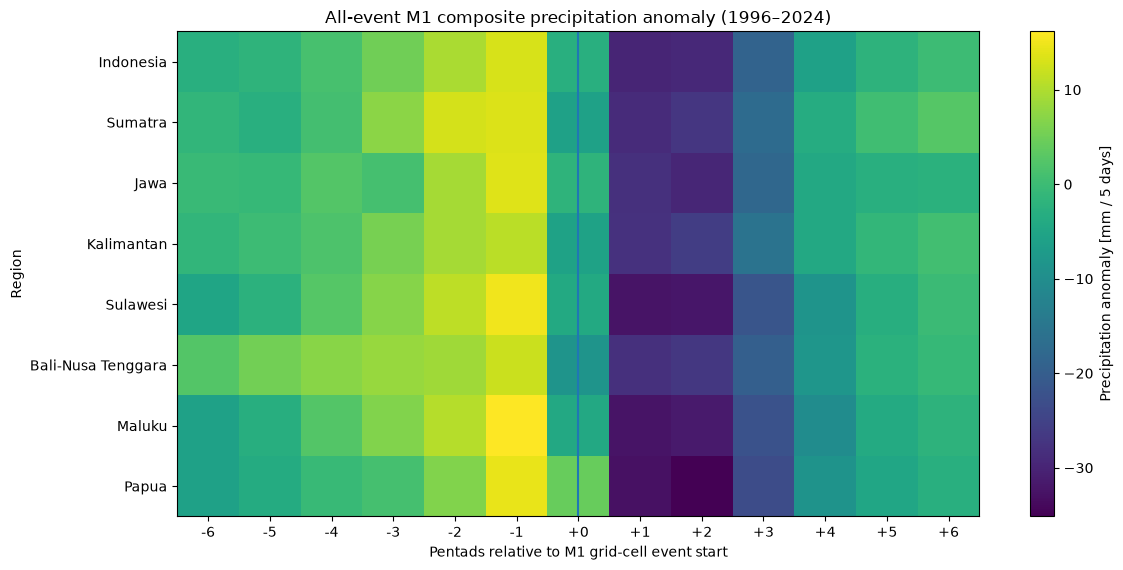

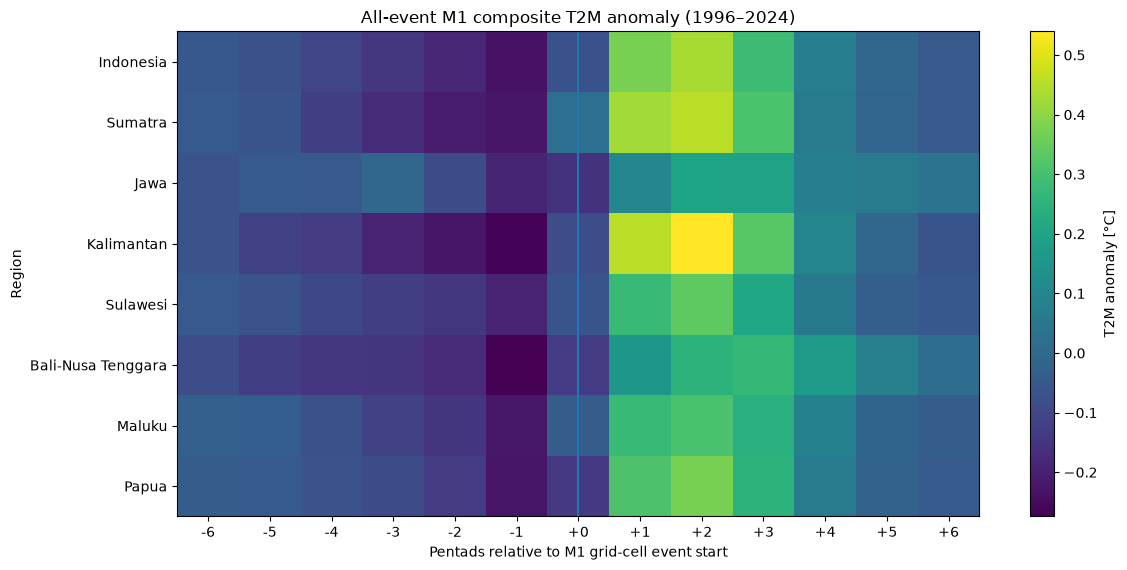

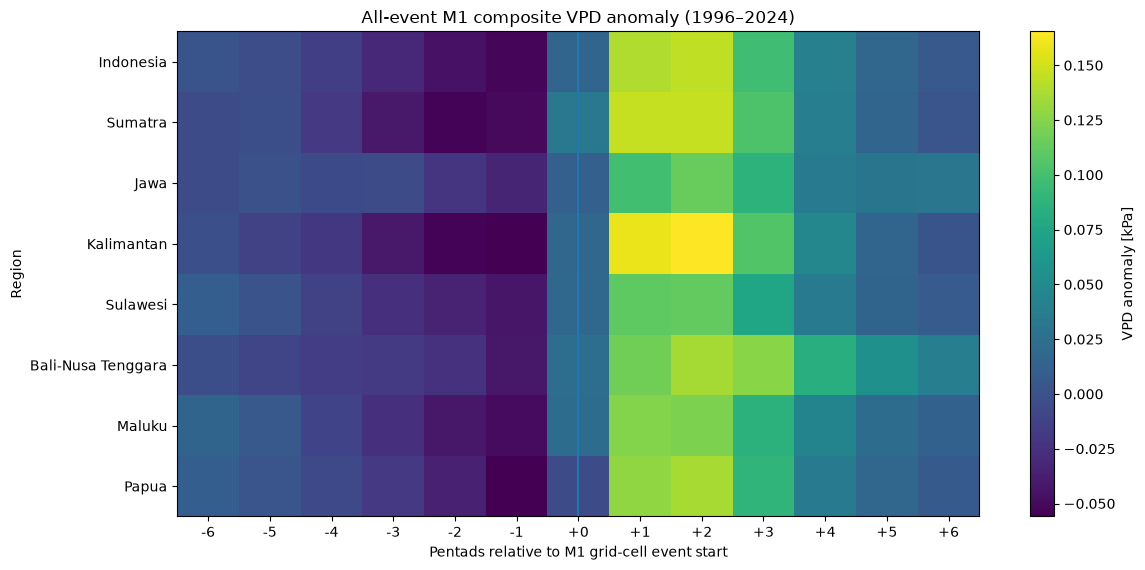

In [24]:
def plot_all_event_heatmap(
    value_col,
    title,
    colorbar_label,
    output_stem,
):
    table = (
        all_event_composite
        .pivot(
            index="region",
            columns="relative_pentad",
            values=value_col,
        )
        .reindex(REGIONS)
    )

    fig, ax = plt.subplots(
        figsize=(12, 5.8)
    )

    im = ax.imshow(
        table.values,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_yticks(
        np.arange(len(REGIONS))
    )
    ax.set_yticklabels(REGIONS)

    lags = table.columns.to_numpy(dtype=int)

    ax.set_xticks(
        np.arange(len(lags))
    )
    ax.set_xticklabels(
        [f"{lag:+d}" for lag in lags]
    )

    zero = np.where(lags == 0)[0]

    if zero.size:
        ax.axvline(
            zero[0],
            linewidth=1.5,
        )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    ax.set(
        xlabel="Pentads relative to M1 grid-cell event start",
        ylabel="Region",
        title=title,
    )

    fig.tight_layout()

    if SAVE_PNG:
        fig.savefig(
            OUTPUT_DIR / f"{output_stem}.png",
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

    if SAVE_PDF:
        fig.savefig(
            OUTPUT_DIR / f"{output_stem}.pdf",
            bbox_inches="tight",
        )

    plt.show()


plot_all_event_heatmap(
    "tp_anom_mm",
    (
        "All-event M1 composite precipitation anomaly "
        f"({ALL_EVENT_START_YEAR}–{ALL_EVENT_END_YEAR})"
    ),
    "Precipitation anomaly [mm / 5 days]",
    "heatmap_all_event_M1_tp_anomaly",
)

plot_all_event_heatmap(
    "t2m_anom_c",
    (
        "All-event M1 composite T2M anomaly "
        f"({ALL_EVENT_START_YEAR}–{ALL_EVENT_END_YEAR})"
    ),
    "T2M anomaly [°C]",
    "heatmap_all_event_M1_t2m_anomaly",
)

plot_all_event_heatmap(
    "vpd_anom_kpa",
    (
        "All-event M1 composite VPD anomaly "
        f"({ALL_EVENT_START_YEAR}–{ALL_EVENT_END_YEAR})"
    ),
    "VPD anomaly [kPa]",
    "heatmap_all_event_M1_vpd_anomaly",
)


## 19. Dua anchor setiap kasus

**Anchor utama:** national maximum `new-onset area`.

Ini lebih dekat ke fase rapid development daripada drought-core peak.

**Anchor sekunder:** national maximum drought-core area.

Window driver = ±6 pentad dari onset-area peak, kontinu lintas tahun.


In [25]:
case_anchor_rows = []

for year in CASE_YEARS:
    subset = (
        national_fd[
            national_fd["year"] == year
        ]
        .sort_values("time_index")
        .copy()
    )

    if subset.empty:
        raise RuntimeError(
            f"Tahun {year} tidak ada di national FD metrics."
        )

    onset_peak = subset.loc[
        subset[
            "national_new_onset_area_percent"
        ].idxmax()
    ]

    core_peak = subset.loc[
        subset[
            "national_drought_core_area_percent"
        ].idxmax()
    ]

    case_anchor_rows.append({
        "case_year": int(year),
        "case_class": (
            "robust_national_case"
            if year in MAIN_CASE_YEARS
            else "supplementary_sensitivity_dependent_case"
        ),
        "onset_peak_time_index": int(
            onset_peak["time_index"]
        ),
        "onset_peak_pentad": int(
            onset_peak["pentad"]
        ),
        "national_new_onset_area_percent": float(
            onset_peak[
                "national_new_onset_area_percent"
            ]
        ),
        "core_peak_time_index": int(
            core_peak["time_index"]
        ),
        "core_peak_pentad": int(
            core_peak["pentad"]
        ),
        "national_core_peak_area_percent": float(
            core_peak[
                "national_drought_core_area_percent"
            ]
        ),
        "core_peak_relative_to_onset_pentads": int(
            core_peak["time_index"]
            - onset_peak["time_index"]
        ),
    })

case_anchors = pd.DataFrame(case_anchor_rows)

CASE_ANCHOR_FILE = (
    OUTPUT_DIR
    / "fd_M1_case_meteorological_driver_anchors.csv"
)

case_anchors.to_csv(
    CASE_ANCHOR_FILE,
    index=False,
)

display(case_anchors)


,case_year,case_class,onset_peak_time_index,onset_peak_pentad,national_new_onset_area_percent,core_peak_time_index,core_peak_pentad,national_core_peak_area_percent,core_peak_relative_to_onset_pentads
0,2003,robust_national_case,611,28,34.006767,616,33,82.068881,5
1,1997,robust_national_case,174,29,27.568804,177,32,72.667859,3
2,2015,robust_national_case,1494,35,26.264142,1498,39,70.586039,4
3,2014,robust_national_case,1389,3,24.635745,1394,8,59.677940,5
4,2004,supplementary_sensitivity_dependent_case,682,26,38.812570,685,29,51.872052,3


## 20. Synchronized driver windows ±6 pentad

In [26]:
driver_window_rows = []

for anchor in case_anchors.itertuples(index=False):
    start = (
        int(anchor.onset_peak_time_index)
        - DRIVER_WINDOW_RADIUS
    )

    stop = (
        int(anchor.onset_peak_time_index)
        + DRIVER_WINDOW_RADIUS
    )

    for t in range(start, stop + 1):
        if t < 0 or t >= len(time_lookup):
            continue

        relative = (
            t - int(anchor.onset_peak_time_index)
        )

        actual = time_lookup[
            time_lookup["time_index"] == t
        ].iloc[0]

        subset = regional_met[
            regional_met["time_index"] == t
        ]

        for row in subset.itertuples(index=False):
            driver_window_rows.append({
                "case_year": int(anchor.case_year),
                "case_class": anchor.case_class,
                "relative_pentad": int(relative),
                "time_index": int(t),
                "actual_year": int(actual["year"]),
                "actual_pentad": int(actual["pentad"]),
                "region": row.region,
                "tp_mm": row.tp_mm,
                "tp_anom_mm": row.tp_anom_mm,
                "t2m_c": row.t2m_c,
                "t2m_anom_c": row.t2m_anom_c,
                "d2m_c": row.d2m_c,
                "d2m_anom_c": row.d2m_anom_c,
                "vpd_kpa": row.vpd_kpa,
                "vpd_anom_kpa": row.vpd_anom_kpa,
                "core_peak_relative_to_onset_pentads": int(
                    anchor.core_peak_relative_to_onset_pentads
                ),
            })

driver_windows = pd.DataFrame(driver_window_rows)

DRIVER_WINDOW_FILE = (
    OUTPUT_DIR
    / "fd_M1_case_driver_windows_onset_pm6.csv"
)

driver_windows.to_csv(
    DRIVER_WINDOW_FILE,
    index=False,
)

display(
    driver_windows[
        (driver_windows["case_year"] == 2003)
        & (driver_windows["region"] == "Indonesia")
    ]
)


,case_year,case_class,relative_pentad,time_index,actual_year,actual_pentad,region,tp_mm,tp_anom_mm,t2m_c,t2m_anom_c,d2m_c,d2m_anom_c,vpd_kpa,vpd_anom_kpa,core_peak_relative_to_onset_pentads
0,2003,robust_national_case,-6,605,2003,22,Indonesia,45.535257,-5.695781,24.507878,-0.076003,22.441564,-0.123280,0.384708,0.006265,5
8,2003,robust_national_case,-5,606,2003,23,Indonesia,47.353984,-5.400397,24.533138,-0.068973,22.542884,-0.070952,0.370812,-0.002134,5
16,2003,robust_national_case,-4,607,2003,24,Indonesia,49.362197,-1.791562,24.659383,0.043783,22.686907,0.045447,0.370401,-0.000123,5
24,2003,robust_national_case,-3,608,2003,25,Indonesia,53.652656,3.531144,24.662934,0.001632,22.791033,0.128745,0.351706,-0.023716,5
32,2003,robust_national_case,-2,609,2003,26,Indonesia,54.150242,5.806154,24.739786,0.030214,22.775719,0.118291,0.368341,-0.016347,5
40,2003,robust_national_case,-1,610,2003,27,Indonesia,47.355497,3.975276,24.481281,-0.254378,22.524495,-0.068385,0.362017,-0.038247,5
48,2003,robust_national_case,0,611,2003,28,Indonesia,17.707804,-22.328323,24.893288,0.130433,22.012709,-0.515709,0.529933,0.112532,5
56,2003,robust_national_case,1,612,2003,29,Indonesia,9.302867,-28.834515,25.187636,0.492752,21.803778,-0.628700,0.626548,0.205478,5
64,2003,robust_national_case,2,613,2003,30,Indonesia,8.495028,-29.143043,24.987087,0.376183,21.423773,-0.922632,0.647704,0.228405,5
72,2003,robust_national_case,3,614,2003,31,Indonesia,8.838781,-30.164909,25.219111,0.678110,21.516415,-0.741645,0.683971,0.263182,5


## 21. Pre-onset/onset meteorological fingerprint

In [27]:
pre_onset = (
    driver_windows[
        driver_windows[
            "relative_pentad"
        ].isin(PRE_ONSET_LAGS)
    ]
    .groupby(
        ["case_year", "case_class", "region"],
        as_index=False,
    )
    .agg(
        pre_onset_tp_anom_mm=(
            "tp_anom_mm",
            "mean",
        ),
        pre_onset_t2m_anom_c=(
            "t2m_anom_c",
            "mean",
        ),
        pre_onset_vpd_anom_kpa=(
            "vpd_anom_kpa",
            "mean",
        ),
    )
)

PRE_ONSET_FILE = (
    OUTPUT_DIR
    / "fd_M1_case_pre_onset_meteorological_fingerprint.csv"
)

pre_onset.to_csv(
    PRE_ONSET_FILE,
    index=False,
)

display(
    pre_onset.sort_values(
        ["case_year", "region"]
    )
)


,case_year,case_class,region,pre_onset_tp_anom_mm,pre_onset_t2m_anom_c,pre_onset_vpd_anom_kpa
0,1997,robust_national_case,Bali-Nusa Tenggara,-6.854936,0.102459,0.023614
1,1997,robust_national_case,Indonesia,-5.884125,-0.279360,0.021925
2,1997,robust_national_case,Jawa,-4.878294,-0.210349,-0.012029
3,1997,robust_national_case,Kalimantan,-6.084815,-0.336782,0.008915
4,1997,robust_national_case,Maluku,-9.031960,-0.295715,0.019338
5,1997,robust_national_case,Papua,-6.298969,-0.210108,0.045986
6,1997,robust_national_case,Sulawesi,-17.240174,-0.195458,0.056231
7,1997,robust_national_case,Sumatra,-0.660555,-0.375079,0.012553
8,2003,robust_national_case,Bali-Nusa Tenggara,-5.859178,-0.151149,0.065677
9,2003,robust_national_case,Indonesia,-4.182297,-0.031244,0.019313


## 22. Konsistensi tanda anomali empat kasus utama

In [28]:
main_pre = pre_onset[
    pre_onset["case_year"].isin(
        MAIN_CASE_YEARS
    )
].copy()

sign_consistency = (
    main_pre
    .groupby("region", as_index=False)
    .agg(
        dry_precip_fraction=(
            "pre_onset_tp_anom_mm",
            lambda x: float(
                np.mean(np.asarray(x) < 0)
            ),
        ),
        warm_fraction=(
            "pre_onset_t2m_anom_c",
            lambda x: float(
                np.mean(np.asarray(x) > 0)
            ),
        ),
        high_vpd_fraction=(
            "pre_onset_vpd_anom_kpa",
            lambda x: float(
                np.mean(np.asarray(x) > 0)
            ),
        ),
        mean_tp_anom_mm=(
            "pre_onset_tp_anom_mm",
            "mean",
        ),
        mean_t2m_anom_c=(
            "pre_onset_t2m_anom_c",
            "mean",
        ),
        mean_vpd_anom_kpa=(
            "pre_onset_vpd_anom_kpa",
            "mean",
        ),
    )
)

SIGN_FILE = (
    OUTPUT_DIR
    / "fd_M1_main_cases_driver_sign_consistency.csv"
)

sign_consistency.to_csv(
    SIGN_FILE,
    index=False,
)

display(sign_consistency)


,region,dry_precip_fraction,warm_fraction,high_vpd_fraction,mean_tp_anom_mm,mean_t2m_anom_c,mean_vpd_anom_kpa
0,Bali-Nusa Tenggara,1.00,0.5,1.00,-7.270485,0.009549,0.041093
1,Indonesia,0.50,0.0,0.50,-0.024033,-0.189795,-0.004978
2,Jawa,0.75,0.0,0.25,-2.058083,-0.211227,0.022914
3,Kalimantan,0.50,0.0,0.50,-1.361783,-0.284968,-0.015217
4,Maluku,0.75,0.0,0.50,-2.485679,-0.148282,-0.004157
5,Papua,0.25,0.0,0.25,6.409914,-0.160176,-0.022597
6,Sulawesi,0.75,0.0,0.25,-3.894547,-0.211798,-0.006217
7,Sumatra,0.75,0.5,0.75,-0.657974,-0.125336,0.008347


## 23. Fungsi heatmap driver

In [29]:
REGION_ORDER = REGIONS


def plot_driver_heatmap(
    data,
    value_col,
    title,
    colorbar_label,
    output_stem,
    core_relative=None,
):
    table = (
        data
        .pivot(
            index="region",
            columns="relative_pentad",
            values=value_col,
        )
        .reindex(REGION_ORDER)
    )

    fig, ax = plt.subplots(figsize=(12, 5.8))

    im = ax.imshow(
        table.values,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_yticks(
        np.arange(len(REGION_ORDER))
    )
    ax.set_yticklabels(REGION_ORDER)

    lags = table.columns.to_numpy(dtype=int)

    ax.set_xticks(
        np.arange(len(lags))
    )
    ax.set_xticklabels(
        [f"{lag:+d}" for lag in lags]
    )

    onset_x = np.where(lags == 0)[0]

    if onset_x.size:
        ax.axvline(
            onset_x[0],
            linewidth=1.5,
        )

    if core_relative is not None:
        core_x = np.where(
            lags == int(core_relative)
        )[0]

        if core_x.size:
            ax.axvline(
                core_x[0],
                linewidth=1.0,
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    ax.set(
        xlabel=(
            "Pentads relative to national new-onset-area peak "
            "(0 = onset-area peak)"
        ),
        ylabel="Region",
        title=title,
    )

    fig.tight_layout()

    if SAVE_PNG:
        fig.savefig(
            OUTPUT_DIR / f"{output_stem}.png",
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

    if SAVE_PDF:
        fig.savefig(
            OUTPUT_DIR / f"{output_stem}.pdf",
            bbox_inches="tight",
        )

    plt.show()


## 24. Heatmap precipitation, T2M, dan VPD tiap kasus

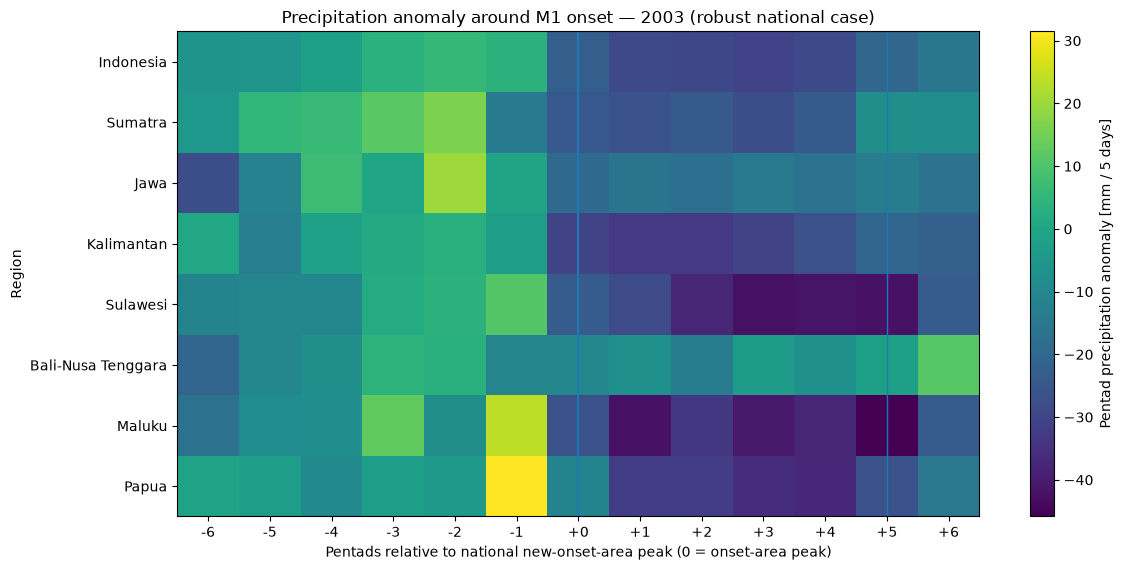

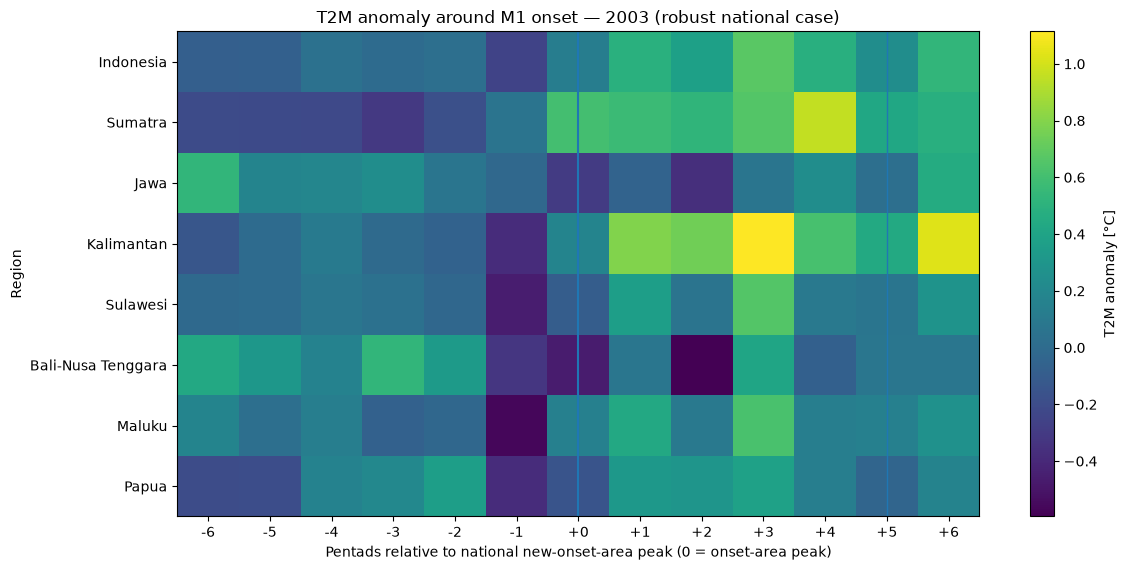

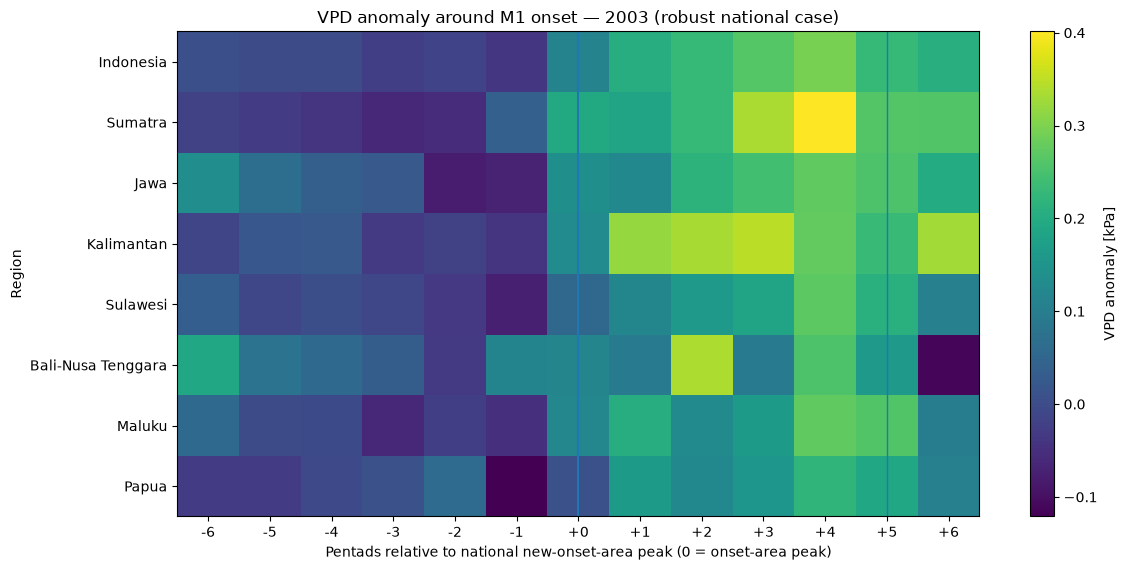

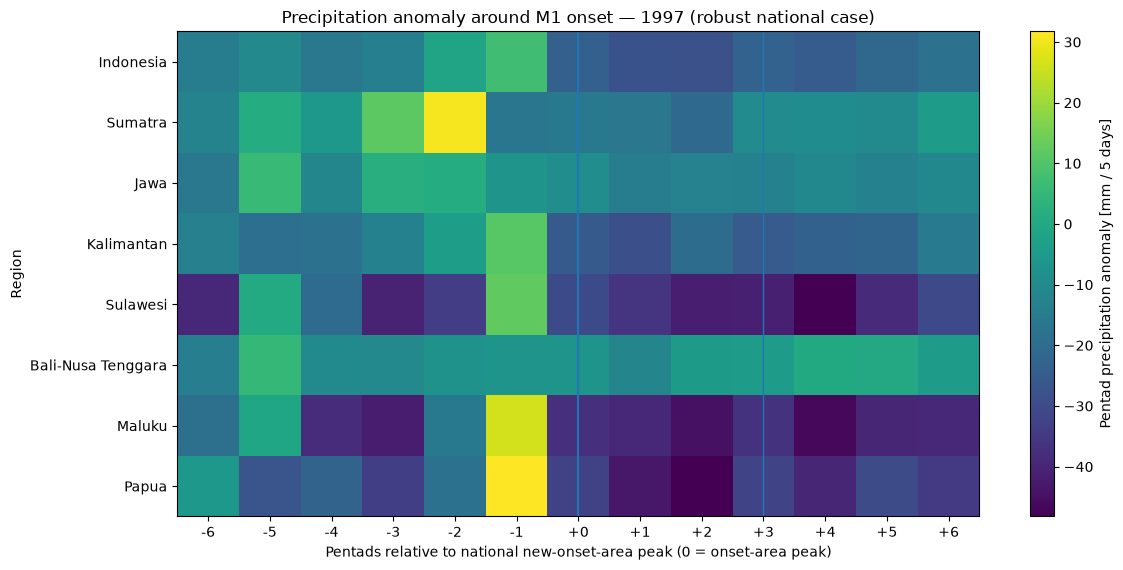

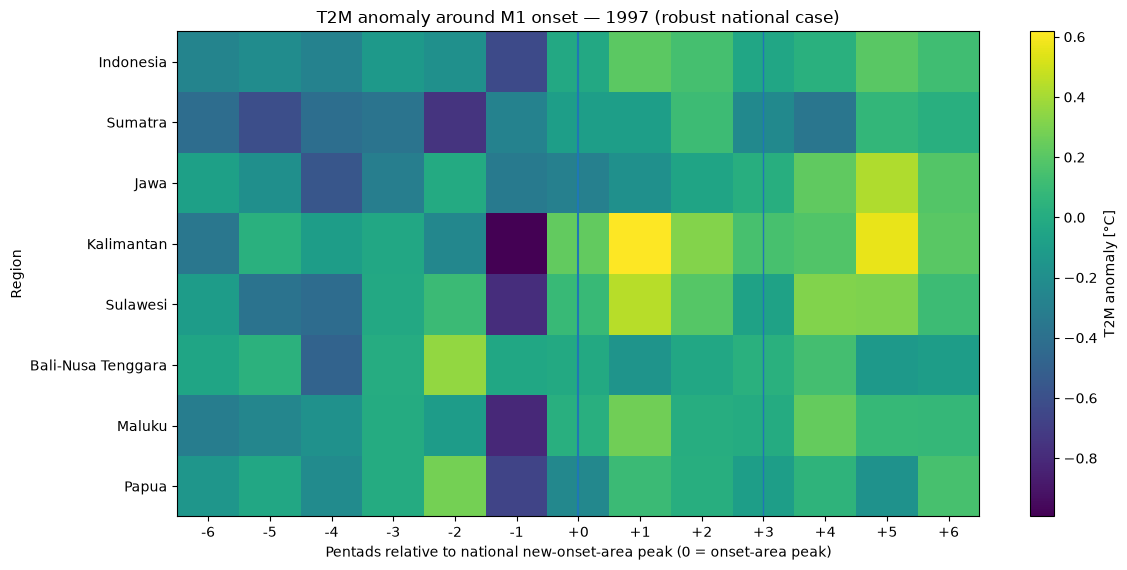

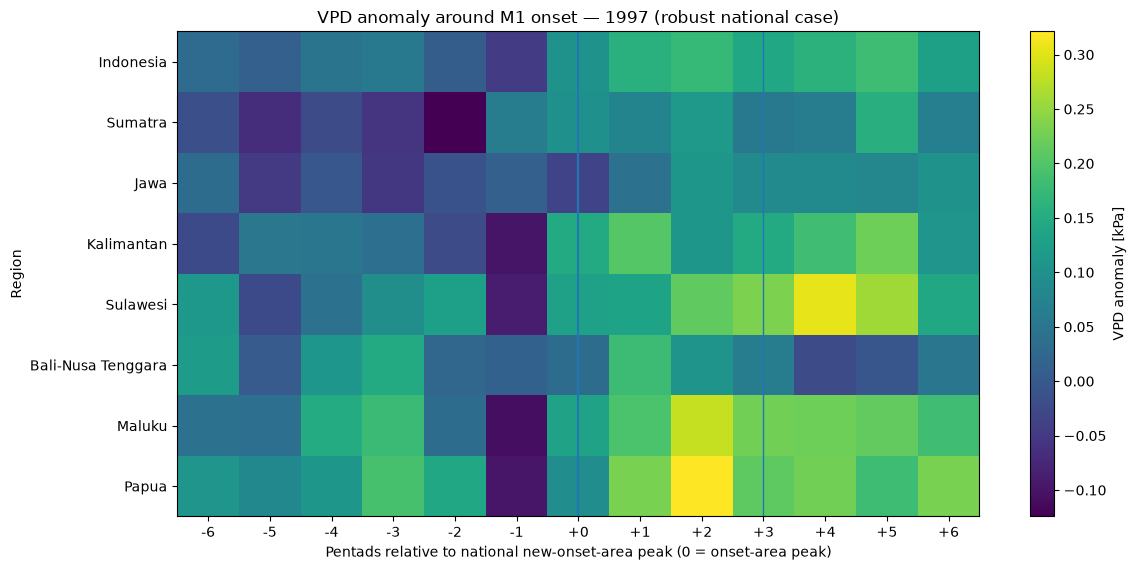

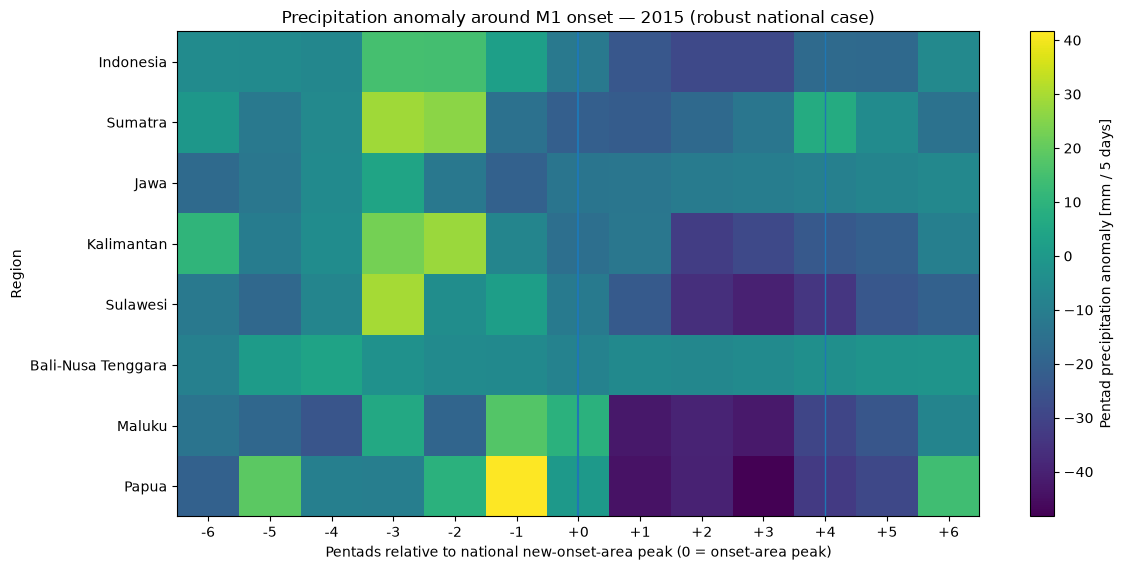

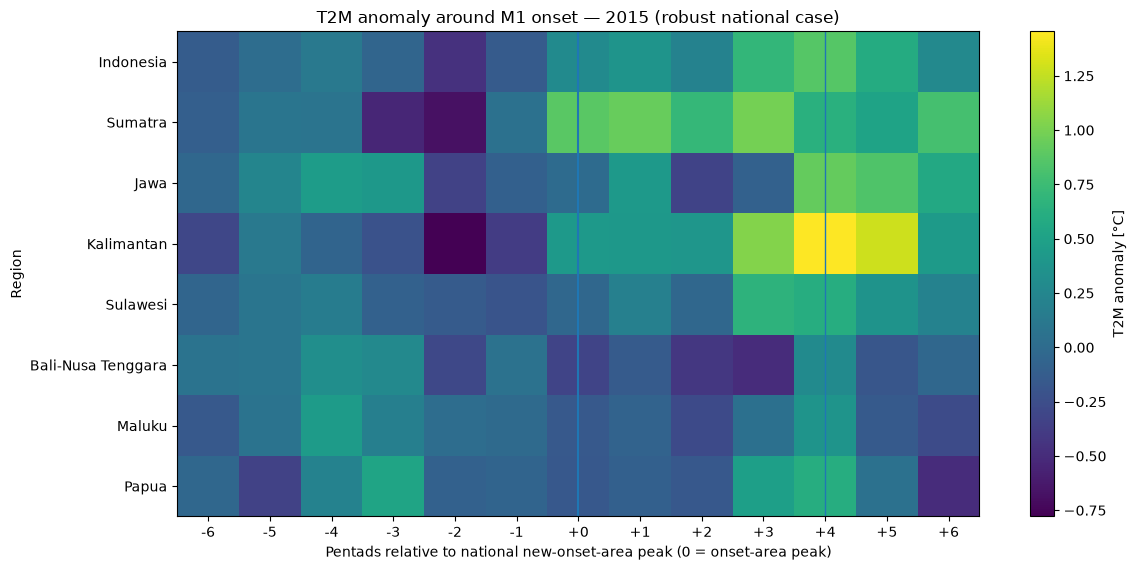

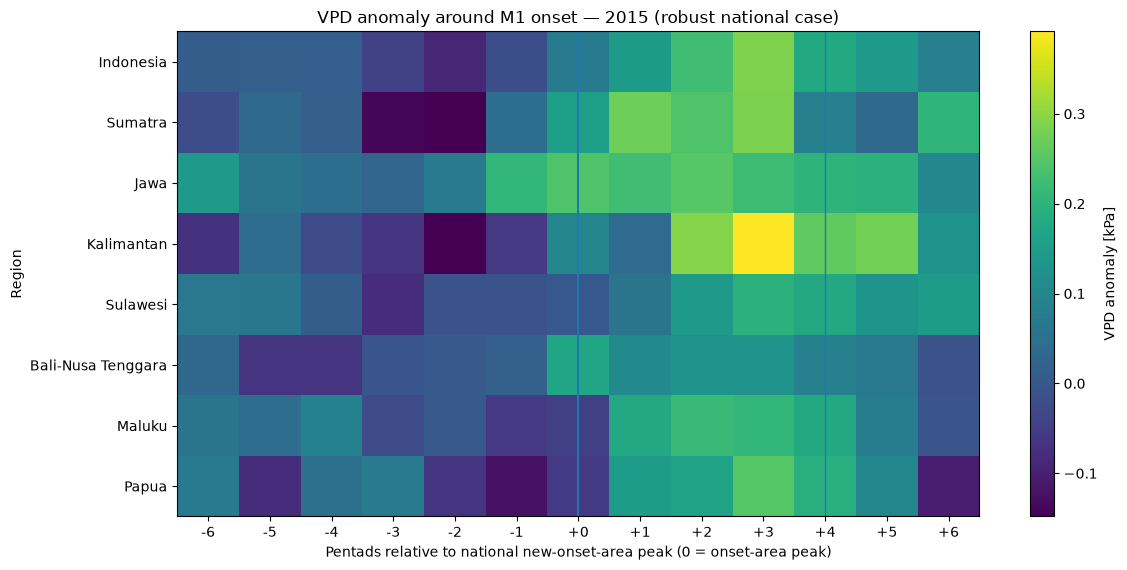

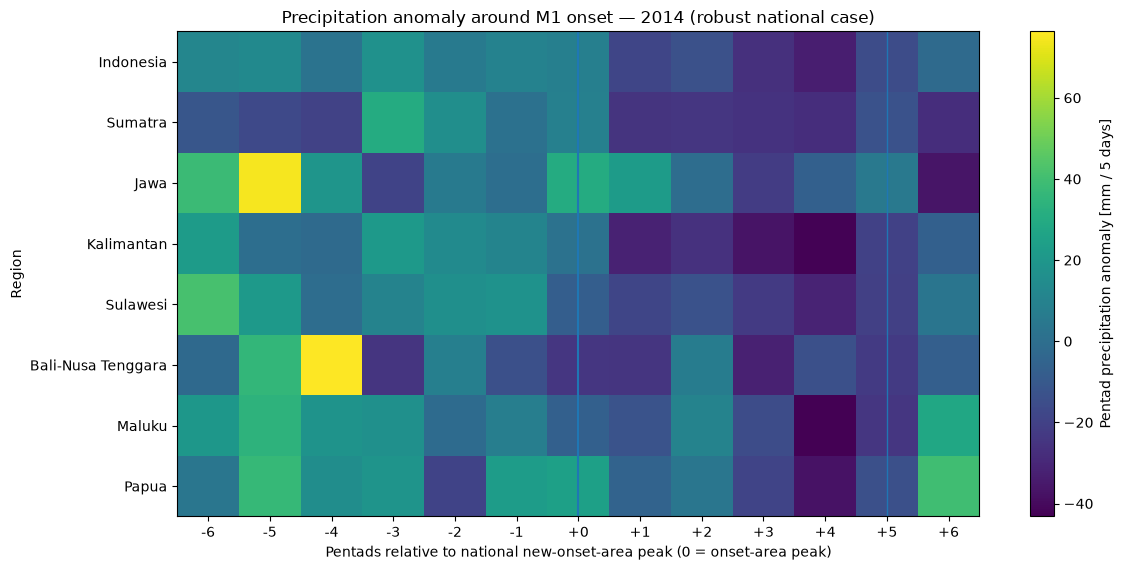

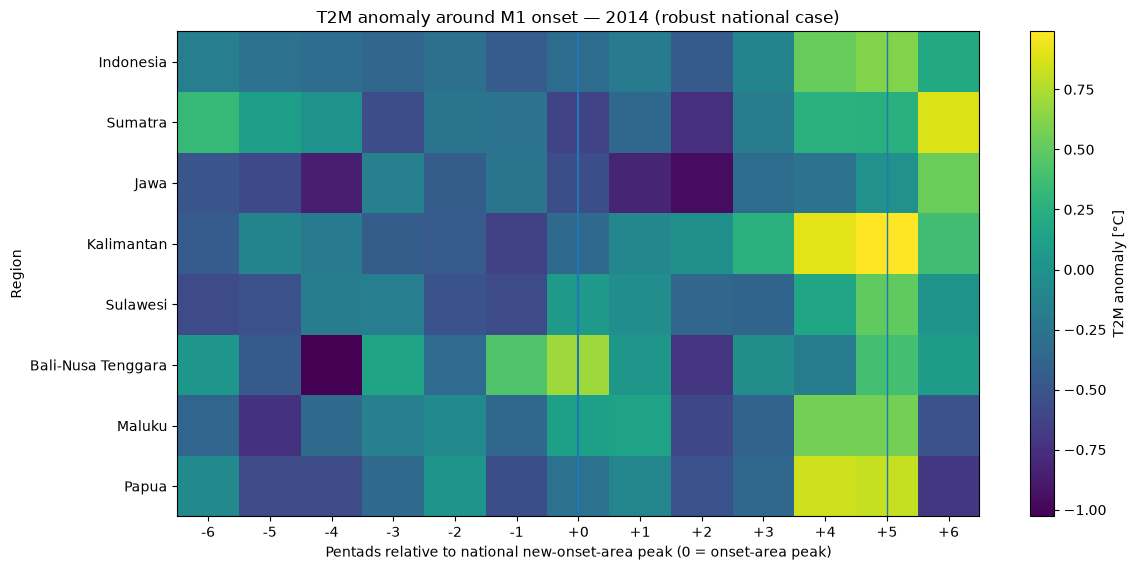

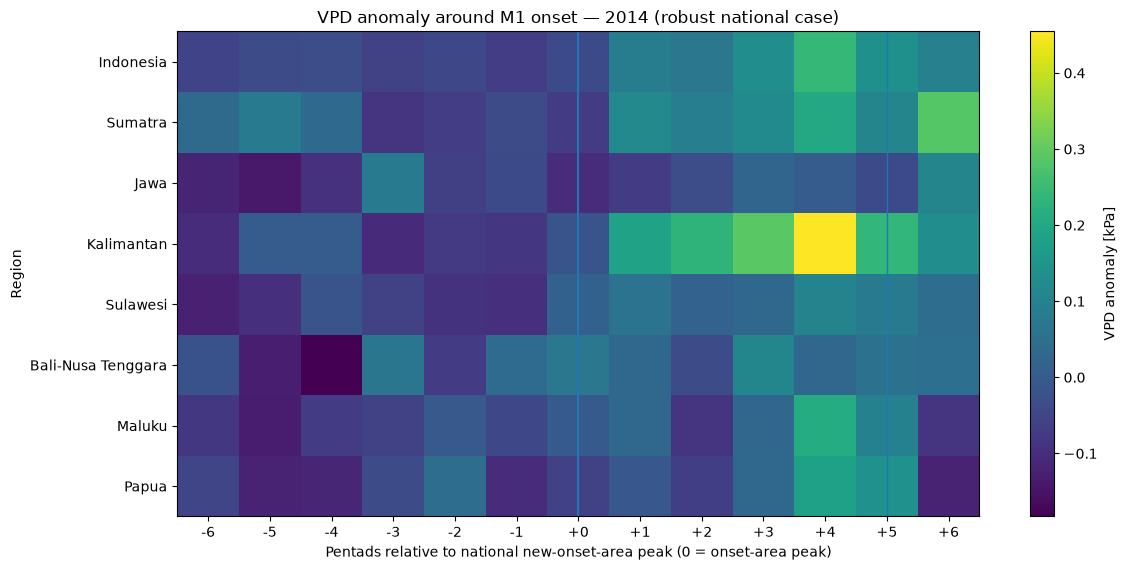

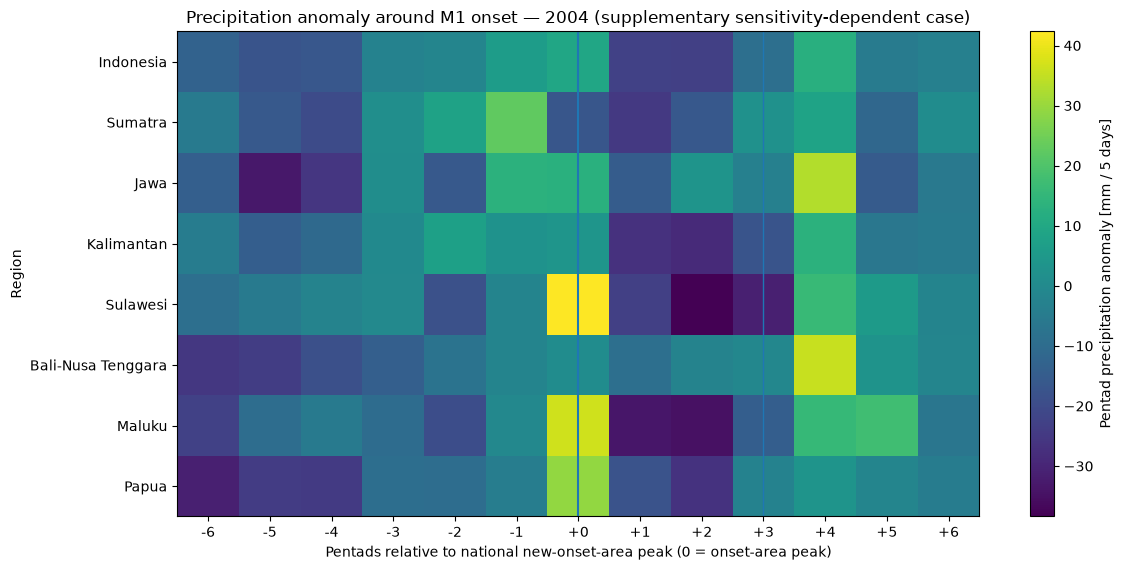

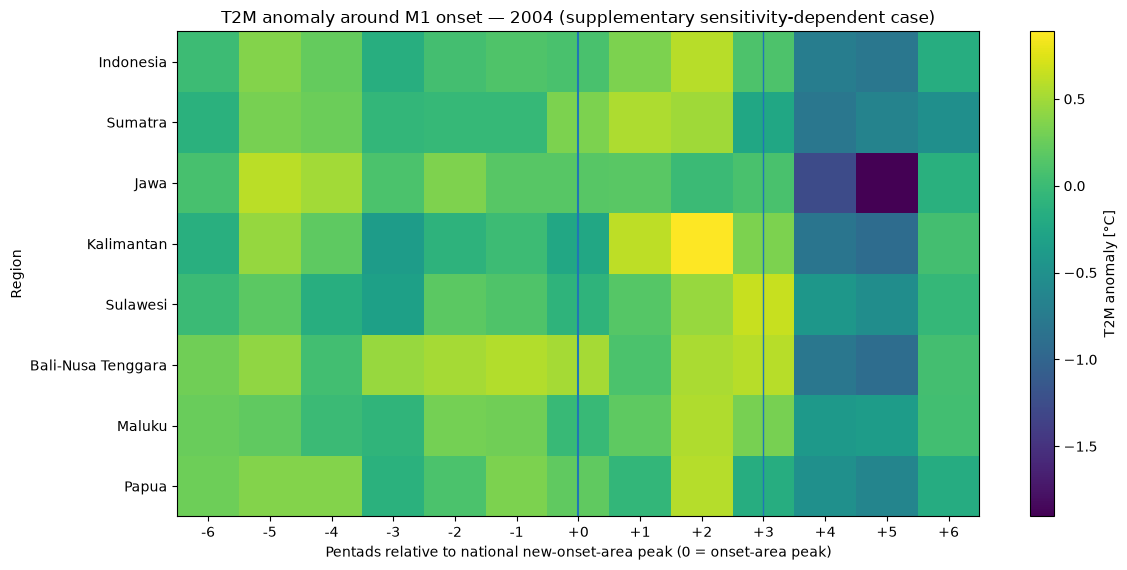

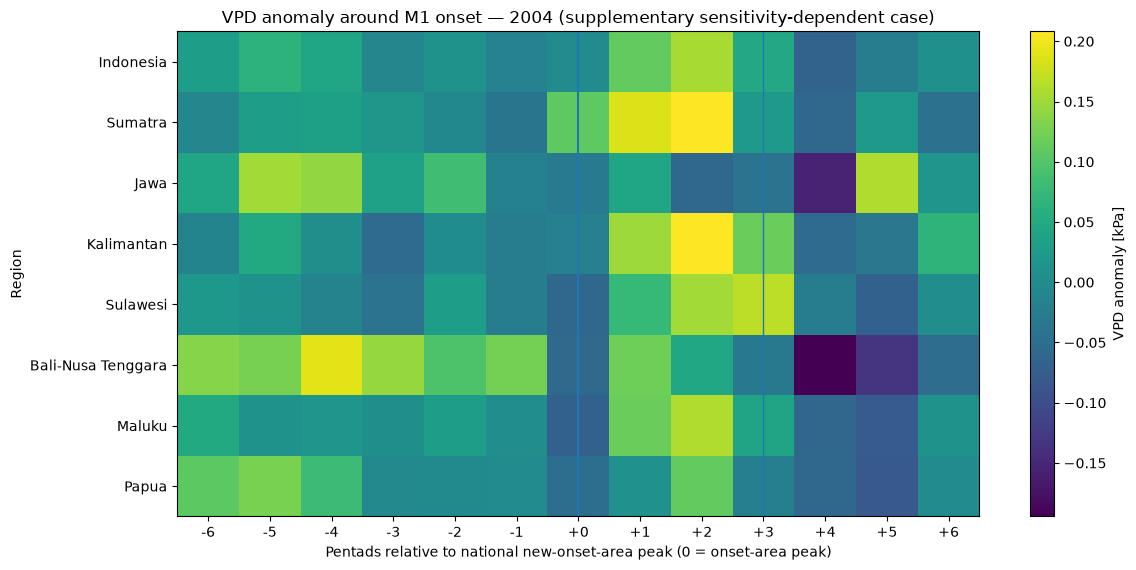

In [30]:
for year in CASE_YEARS:
    case = driver_windows[
        driver_windows["case_year"] == year
    ]

    anchor = case_anchors[
        case_anchors["case_year"] == year
    ].iloc[0]

    core_relative = int(
        anchor[
            "core_peak_relative_to_onset_pentads"
        ]
    )

    label = (
        "robust national case"
        if year in MAIN_CASE_YEARS
        else "supplementary sensitivity-dependent case"
    )

    plot_driver_heatmap(
        case,
        "tp_anom_mm",
        (
            f"Precipitation anomaly around M1 onset — "
            f"{year} ({label})"
        ),
        "Pentad precipitation anomaly [mm / 5 days]",
        f"heatmap_driver_tp_anomaly_{year}",
        core_relative=core_relative,
    )

    plot_driver_heatmap(
        case,
        "t2m_anom_c",
        (
            f"T2M anomaly around M1 onset — "
            f"{year} ({label})"
        ),
        "T2M anomaly [°C]",
        f"heatmap_driver_t2m_anomaly_{year}",
        core_relative=core_relative,
    )

    plot_driver_heatmap(
        case,
        "vpd_anom_kpa",
        (
            f"VPD anomaly around M1 onset — "
            f"{year} ({label})"
        ),
        "VPD anomaly [kPa]",
        f"heatmap_driver_vpd_anomaly_{year}",
        core_relative=core_relative,
    )


## 25. Composite empat kasus robust nasional

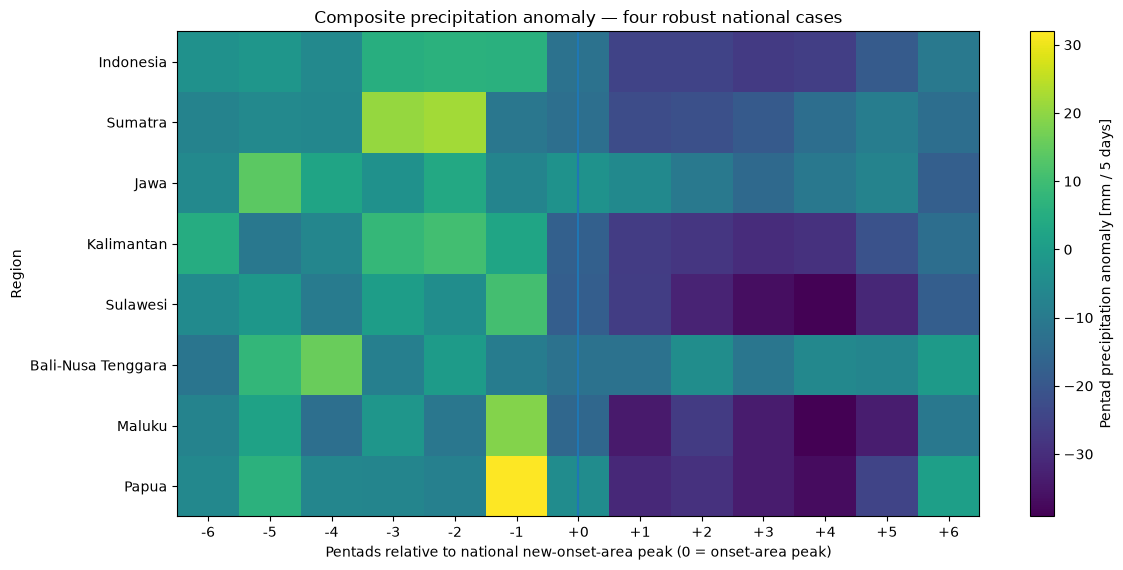

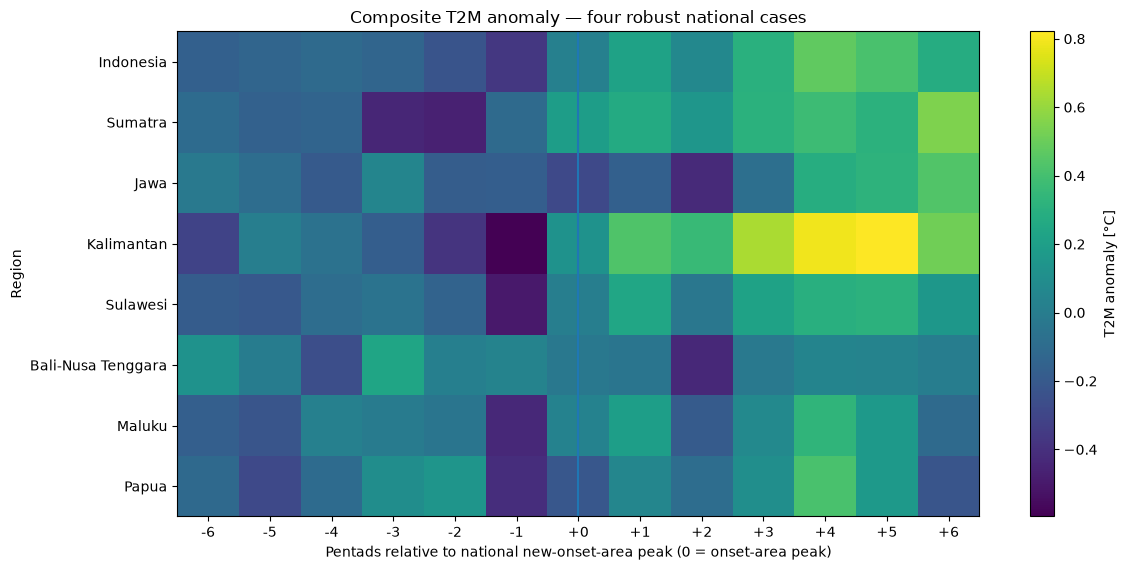

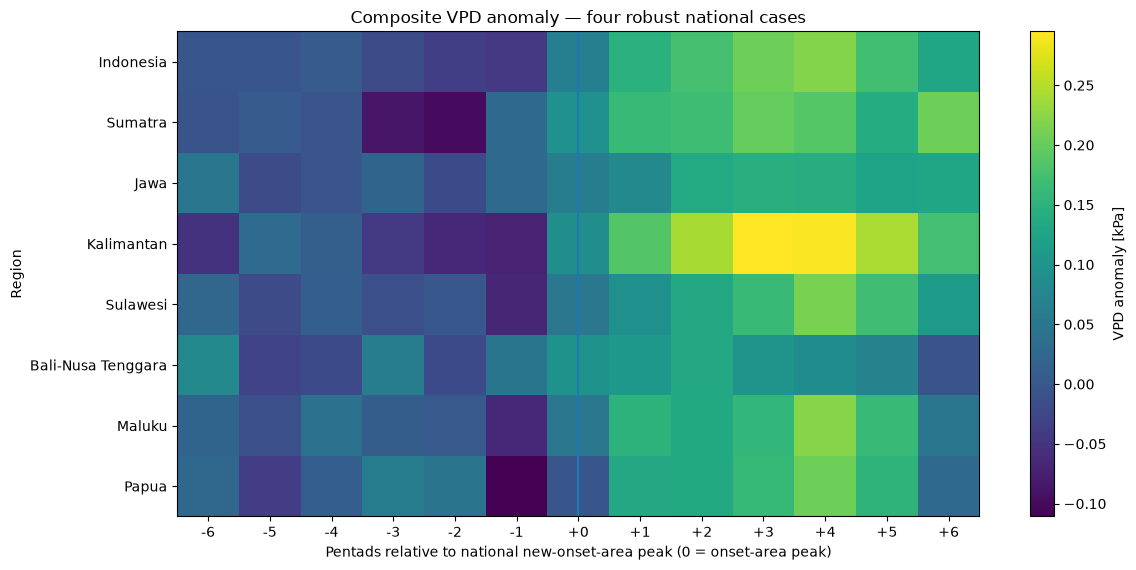

In [31]:
main_windows = driver_windows[
    driver_windows["case_year"].isin(
        MAIN_CASE_YEARS
    )
]

composite = (
    main_windows
    .groupby(
        ["region", "relative_pentad"],
        as_index=False,
    )
    .agg(
        tp_anom_mm=(
            "tp_anom_mm",
            "mean",
        ),
        t2m_anom_c=(
            "t2m_anom_c",
            "mean",
        ),
        vpd_anom_kpa=(
            "vpd_anom_kpa",
            "mean",
        ),
    )
)

COMPOSITE_FILE = (
    OUTPUT_DIR
    / "fd_M1_main_case_composite_drivers_onset_aligned.csv"
)

composite.to_csv(
    COMPOSITE_FILE,
    index=False,
)

plot_driver_heatmap(
    composite,
    "tp_anom_mm",
    "Composite precipitation anomaly — four robust national cases",
    "Pentad precipitation anomaly [mm / 5 days]",
    "heatmap_composite_tp_anomaly_main_cases",
)

plot_driver_heatmap(
    composite,
    "t2m_anom_c",
    "Composite T2M anomaly — four robust national cases",
    "T2M anomaly [°C]",
    "heatmap_composite_t2m_anomaly_main_cases",
)

plot_driver_heatmap(
    composite,
    "vpd_anom_kpa",
    "Composite VPD anomaly — four robust national cases",
    "VPD anomaly [kPa]",
    "heatmap_composite_vpd_anomaly_main_cases",
)


## 26. Local island onset anchors

In [32]:
m1_island_fd = island_fd_pentad[
    island_fd_pentad["method"] == PRIMARY_METHOD
].copy()

local_anchor_rows = []

for year in CASE_YEARS:
    for island in island_names:
        subset = m1_island_fd[
            (m1_island_fd["year"] == year)
            & (m1_island_fd["island"] == island)
        ].copy()

        if subset.empty:
            continue

        onset_row = subset.loc[
            subset[
                "new_onset_area_percent"
            ].idxmax()
        ]

        lookup = time_lookup[
            (time_lookup["year"] == year)
            & (
                time_lookup["pentad"]
                == int(onset_row["pentad"])
            )
        ]

        if lookup.empty:
            continue

        local_anchor_rows.append({
            "case_year": int(year),
            "island": island,
            "local_onset_peak_pentad": int(
                onset_row["pentad"]
            ),
            "local_onset_peak_time_index": int(
                lookup.iloc[0]["time_index"]
            ),
            "local_new_onset_area_percent": float(
                onset_row[
                    "new_onset_area_percent"
                ]
            ),
        })

local_anchors = pd.DataFrame(local_anchor_rows)

LOCAL_ANCHOR_FILE = (
    OUTPUT_DIR
    / "fd_M1_case_local_island_onset_anchors.csv"
)

local_anchors.to_csv(
    LOCAL_ANCHOR_FILE,
    index=False,
)

display(local_anchors.head(20))


,case_year,island,local_onset_peak_pentad,local_onset_peak_time_index,local_new_onset_area_percent
0,2003,Sumatra,27,610,53.776745
1,2003,Jawa,1,584,54.311000
2,2003,Kalimantan,27,610,44.280668
3,2003,Sulawesi,28,611,43.969587
4,2003,Bali-Nusa Tenggara,15,598,43.381807
5,2003,Maluku,28,611,47.670567
6,2003,Papua,28,611,35.759297
7,1997,Sumatra,28,173,32.320089
8,1997,Jawa,12,157,48.775770
9,1997,Kalimantan,28,173,32.779649


In [33]:
local_driver_rows = []

regional_lookup = (
    regional_met
    .set_index(
        ["region", "time_index"]
    )
    .sort_index()
)

for anchor in local_anchors.itertuples(index=False):
    for lag in range(
        -DRIVER_WINDOW_RADIUS,
        DRIVER_WINDOW_RADIUS + 1,
    ):
        t = (
            int(anchor.local_onset_peak_time_index)
            + lag
        )

        if t < 0 or t >= len(time_lookup):
            continue

        key = (anchor.island, t)

        if key not in regional_lookup.index:
            continue

        row = regional_lookup.loc[key]

        actual = time_lookup[
            time_lookup["time_index"] == t
        ].iloc[0]

        local_driver_rows.append({
            "case_year": int(anchor.case_year),
            "island": anchor.island,
            "relative_pentad": int(lag),
            "time_index": int(t),
            "actual_year": int(actual["year"]),
            "actual_pentad": int(actual["pentad"]),
            "tp_anom_mm": float(row["tp_anom_mm"]),
            "t2m_anom_c": float(row["t2m_anom_c"]),
            "vpd_anom_kpa": float(row["vpd_anom_kpa"]),
        })

local_driver_windows = pd.DataFrame(local_driver_rows)

LOCAL_WINDOW_FILE = (
    OUTPUT_DIR
    / "fd_M1_case_local_island_driver_windows_onset_pm6.csv"
)

local_driver_windows.to_csv(
    LOCAL_WINDOW_FILE,
    index=False,
)

print("Local-onset driver window:", LOCAL_WINDOW_FILE)


Local-onset driver window: D:\ERA5_LAND\output_fd_04_drivers\fd_M1_case_local_island_driver_windows_onset_pm6.csv


## Interpretation guardrails

### Klaim umum tentang FD Indonesia

Gunakan **all-event M1 composite 1996–2024** sebagai dasar utama.

Contoh yang aman, bila hasil mendukung:

> Secara umum, onset M1 flash-drought events di Indonesia disertai oleh
> precipitation anomaly negatif dan peningkatan VPD.

### Klaim case-specific

Gunakan 2003, 1997, 2015, dan 2014 untuk menunjukkan variasi spasial-temporal.
2004 tetap supplementary sensitivity-dependent.

### Jangan melebihkan inferensi

Composite/anomali menunjukkan **asosiasi temporal**.

Notebook 04 saja belum cukup untuk mengatakan:

> VPD menyebabkan FD.

> ENSO menyebabkan event tertentu.

Causal attribution atau large-scale forcing memerlukan analisis tambahan.


## 28. Manifest

In [34]:
manifest = {
    "notebook": "04_meteorological_driver_diagnostics_ALL_EVENT_FINAL.ipynb",
    "meteorological_input_directory": str(ADD_DIR),
    "notebook03c_directory": str(NOTEBOOK03C_DIR),
    "notebook03b_directory": str(NOTEBOOK03B_DIR),
    "M1_detection_file": str(M1_DETECTION_FILE),
    "output_directory": str(OUTPUT_DIR),
    "years": [START_YEAR, END_YEAR],
    "flash_drought_redetected": False,
    "primary_fd_method": PRIMARY_METHOD,
    "main_case_years": MAIN_CASE_YEARS,
    "supplementary_case_years": SUPPLEMENTARY_CASE_YEARS,
    "driver_window_radius_pentads": DRIVER_WINDOW_RADIUS,
    "all_event_start_year": ALL_EVENT_START_YEAR,
    "all_event_end_year": ALL_EVENT_END_YEAR,
    "all_event_lags": ALL_EVENT_LAGS,
    "all_event_unit": "M1 grid-cell event start",
    "anchor_primary": "national maximum new-onset area",
    "anchor_secondary": "national maximum drought-core area",
    "precipitation_mode": DETECTED_PRECIPITATION_MODE,
    "vpd_download_required": False,
    "vpd_source": "derived hourly from ERA5-Land T2M and D2M",
    "additional_required_variables": [],
    "optional_future_variables": [
        "total_evaporation",
        "surface_solar_radiation_downwards",
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "surface_pressure",
    ],
    "large_scale_context_deferred": [
        "ENSO index",
        "IOD/DMI index",
    ],
    "output_files": {
        "yearly_pentad_dir": str(YEARLY_PENTAD_DIR),
        "all_event_anomaly_cube": str(ALL_EVENT_CUBE_FILE),
        "all_event_composite": str(ALL_EVENT_COMPOSITE_FILE),
        "all_event_pre_onset_fingerprint": str(ALL_EVENT_PRE_FILE),
        "climatology": str(CLIMATOLOGY_FILE),
        "regional_meteorology": str(REGIONAL_MET_FILE),
        "case_anchors": str(CASE_ANCHOR_FILE),
        "national_driver_windows": str(DRIVER_WINDOW_FILE),
        "pre_onset_fingerprint": str(PRE_ONSET_FILE),
        "sign_consistency": str(SIGN_FILE),
        "main_case_composite": str(COMPOSITE_FILE),
        "local_island_anchors": str(LOCAL_ANCHOR_FILE),
        "local_island_driver_windows": str(LOCAL_WINDOW_FILE),
    },
    "created_utc": str(
        pd.Timestamp.now(tz="UTC")
    ),
}

MANIFEST_FILE = (
    OUTPUT_DIR
    / "meteorological_driver_manifest_04.json"
)

with MANIFEST_FILE.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        manifest,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Manifest:", MANIFEST_FILE)


Manifest: D:\ERA5_LAND\output_fd_04_drivers\meteorological_driver_manifest_04.json


## 29. Selesai

In [35]:
climatology_ds.close()
island_mask_ds.close()
m1_detection_ds.close()
anomaly_cube.close()

print("=" * 72)
print("NOTEBOOK 04 ALL-EVENT + CASE STUDIES SELESAI")
print("=" * 72)
print("Output:", OUTPUT_DIR)
print()
print("Analisis selesai:")
print("- all-event M1 composite 1996–2024")
print("- national + macro-island meteorological anomalies")
print("- 2003 / 1997 / 2015 / 2014 case studies")
print("- 2004 supplementary sensitivity-dependent case")
print()
print("Variabel inti:")
print("- precipitation")
print("- T2M")
print("- D2M")
print("- VPD (derived from T2M + D2M)")
print()
print(
    "Tidak ada data meteorologi tambahan yang wajib "
    "untuk diagnosis inti Notebook 04."
)
print(
    "Next recommended step: ENSO + IOD large-scale context "
    "setelah hasil 04 diperiksa."
)


NOTEBOOK 04 ALL-EVENT + CASE STUDIES SELESAI
Output: D:\ERA5_LAND\output_fd_04_drivers

Analisis selesai:
- all-event M1 composite 1996–2024
- national + macro-island meteorological anomalies
- 2003 / 1997 / 2015 / 2014 case studies
- 2004 supplementary sensitivity-dependent case

Variabel inti:
- precipitation
- T2M
- D2M
- VPD (derived from T2M + D2M)

Tidak ada data meteorologi tambahan yang wajib untuk diagnosis inti Notebook 04.
Next recommended step: ENSO + IOD large-scale context setelah hasil 04 diperiksa.
